## **IMPORTS**

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent))

In [2]:
import os
from dotenv import load_dotenv

import src.experiments.config as cfg_module
import src.experiments.simulation as sim_module
import src.experiments.simulation_greedy as sim_greedy
from src.experiments.run import define_agents
from src.metrics.plots_metrics import *
from src.metrics.plots_metrics_comparison import *
from src.metrics.other_metrics import *

pygame 2.6.1 (SDL 2.28.4, Python 3.12.0)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [3]:
load_dotenv()

ROOT_PATH = os.getenv("ROOT_PATH")
OUTPUT_DIR = 'outputs'
OUTPUT_PATH = f'{ROOT_PATH}/{OUTPUT_DIR}'
os.makedirs(OUTPUT_PATH, exist_ok=True)

print(f'--> outputs logs in: {OUTPUT_PATH}')

--> outputs logs in: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs


## **UTILS**

### **CONFIG**

In [4]:
# --- CONFIG FUNCTION

def notebook_config(
    total_time=None,
    nb_car=None,
    nb_society=None,
    nb_station=None,
    base_car_behavior=None,
    station_strategy_noise=None,
    log_iter=None
):
    """
    Crée et configure un objet SimulationConfig
    pour les notebooks/tests.
    """

    config = cfg_module.SimulationConfig()

    # ------------------------------------------------ VISUALISATION
    config.set_VISUALIZE(False)

    # ------------------------------------------------ TEMPS
    if total_time is not None:
        config.set_TOTAL_TIME(total_time)

    if log_iter is not None:
        config.set_log_iter(log_iter)

    # ------------------------------------------------ AGENTS
    if nb_car is not None:

        if type(nb_car) is not int:
            raise TypeError(
                f"nb_car doit être un int, reçu : {type(nb_car).__name__}"
            )

        if nb_car <= 0:
            raise ValueError("nb_car doit être > 0")

        config.NB_CARS = nb_car

    if nb_society is not None:

        if type(nb_society) is not int:
            raise TypeError(
                f"nb_society doit être un int, reçu : {type(nb_society).__name__}"
            )

        if nb_society <= 0:
            raise ValueError("nb_society doit être > 0")

        config.NB_SOCIETIES = nb_society

    if nb_station is not None:

        if type(nb_station) is not int:
            raise TypeError(
                f"nb_station doit être un int, reçu : {type(nb_station).__name__}"
            )

        if nb_station <= 0:
            raise ValueError("nb_station doit être > 0")

        config.NB_STATIONS = nb_station

    # ------------------------------------------------ COMPORTEMENTS VOITURES
    if base_car_behavior is not None:

        required_keys = {
            'pres',
            'abs',
            'early',
            'late',
            'noise'
        }

        missing = required_keys - set(base_car_behavior.keys())

        if missing:
            raise ValueError(
                f"Clés manquantes dans base_car_behavior : {missing}"
            )

        total_prob = (
            base_car_behavior['pres']
            + base_car_behavior['abs']
            + base_car_behavior['early']
            + base_car_behavior['late']
        )

        if total_prob != 100:
            raise ValueError(
                f"La somme des probabilités doit valoir 100, reçu : {total_prob}"
            )

        config.BASE_CANCEL_PROB = base_car_behavior.copy()

    # ------------------------------------------------ BRUIT STRATÉGIE STATION
    if station_strategy_noise is not None:

        if not isinstance(station_strategy_noise, (int, float)):
            raise TypeError(
                "station_strategy_noise doit être numérique"
            )

        if station_strategy_noise < 0:
            raise ValueError(
                "station_strategy_noise doit être >= 0"
            )

        config.STRATEGY_NOISE = float(station_strategy_noise)

    return config

In [5]:
# --- EXAMPLE

total_time = 12 * 24 * 1  # une journée
log_iter = 12

nb_car = 50
nb_society = 4
nb_station = 40

strategy_noise = 0.5  # variation proportionnelle ±50%

base_car_behavior = {
    'pres': 75,     # présent et honore la réservation
    'abs': 10,      # no-show complet
    'early': 9,     # annulation anticipée (> 2h avant)
    'late': 6,      # annulation tardive (< 2h avant)
    'noise': 0.15
}

c = notebook_config(total_time=total_time, nb_car=nb_car, nb_society=nb_society,
                nb_station=nb_station, base_car_behavior=base_car_behavior,
                station_strategy_noise=strategy_noise, log_iter=log_iter)

slot_h = c.SLOT_DURATION / 60
dist_slot = c.CAR_SPEED          # m/slot
autonomy_mean = c.CAR_AUTONOMY_PARAMS_KM['mean']
conso = c.ENERGY_CONSUMPTION['quantity_kW'] / c.ENERGY_CONSUMPTION['distance_unit_m']
delta_soc = dist_slot * conso / (c.ENERGY_CONSUMPTION['quantity_kW'] * autonomy_mean / 100)

print(f"Grille            : {c.C_GRID/1e3:.1f} km × {c.C_GRID/1e3:.1f} km")
print(f"Vitesse           : {c.CAR_SPEED} m/slot  ({c.CAR_SPEED/1000/slot_h:.0f} km/h)")
print(f"ΔSoC / slot       : {delta_soc:.5f}  ({1/delta_soc:.0f} slots pour vider)")
print(f"Autonomie moy.    : {autonomy_mean} km")
print(f"Distance max grille traversée avec soc=0.10 : {0.10*autonomy_mean:.0f} km >> {c.C_GRID/1e3:.1f} km ✓")


Grille            : 3.0 km × 3.0 km
Vitesse           : 4167.0 m/slot  (50 km/h)
ΔSoC / slot       : 0.01042  (96 slots pour vider)
Autonomie moy.    : 400 km
Distance max grille traversée avec soc=0.10 : 40 km >> 3.0 km ✓


### **CHARTS**

#### *Demand Satisfaction*

In [6]:
def plot_exact_needs_comparison(exact_values, needs_values, labels, colors,
                                scenario_name, nb_car):

    # Création des graphiques côte à côte
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Graphique Exact --------
    bars1 = axes[0].bar(labels, exact_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Exact Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[0].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[0].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Graphique Needs --------
    bars2 = axes[1].bar(labels, needs_values, color=colors, alpha=0.7)
    

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Needs Satisfaction (%)', fontweight='bold')

    # Ligne horizontale à 100
    axes[1].axhline(y=100, color='black', linestyle='--', linewidth=1, alpha=0.5)
    axes[1].set_ylim(top=105)

    # Affichage des valeurs au milieu des barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height / 2,
            f'{height:.2f}',
            ha='center',
            va='center',
            color='white',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Travel & Waiting*

In [7]:
def plot_travel_waiting_comparison(travel_values, waiting_values, labels, colors,
                                scenario_name, nb_car):

    # Création des subplots
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))

    # -------- Travel Distance --------
    bars1 = axes[0].bar(labels, travel_values, color=colors, alpha=0.7)

    axes[0].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Travel Distance (km)', fontweight='bold')
    axes[0].set_ylabel('Distance (km)')
    axes[0].set_ylim(top = 1.15 * max(travel_values))

    # Valeurs sur les barres
    for bar in bars1:
        height = bar.get_height()
        axes[0].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    # -------- Waiting Time --------
    bars2 = axes[1].bar(labels, waiting_values, color=colors, alpha=0.7)

    axes[1].set_title(f'[{str.upper(scenario_name[:3])}@{nb_car}] Mean Waiting Time (min)', fontweight='bold')
    axes[1].set_ylabel('Time (min)')
    if max(waiting_values) > 0.:
        axes[1].set_ylim(top = 1.15 * max(waiting_values))
    else:
        axes[1].set_ylim(bottom = 0. ,top = 5.)

    # Valeurs sur les barres
    for bar in bars2:
        height = bar.get_height()
        axes[1].text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f'{height:.3f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Scalability*

In [8]:
def plot_mean_response_time_comparison(labels, colors, values, scenario_name, nb_car):

    fig, ax = plt.subplots(figsize=(6, 5))

    bars = ax.bar(labels, values, color=colors, alpha=0.8)

    scenario_tag = f"[{scenario_name[:3].upper()}@{nb_car}]"

    ax.set_title(
        f'{scenario_tag} Mean Response Time (ms)',
        fontweight='bold'
    )

    ax.set_ylabel('Response Time (ms)')

    if max(values) > 0:
        ax.set_ylim(0, 1.15 * max(values))

    # Affichage des valeurs
    for bar in bars:
        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.01 * max(values),
            f'{height:.2f}',
            ha='center',
            va='bottom',
            color='black',
            fontsize=10,
            fontweight='bold'
        )

    plt.tight_layout()
    plt.show()
    plt.close()

#### *Comparison*

In [9]:
def plot_metric_comparison(
    greedy_values,
    bramev_values,
    nb_car_list,
    ylabel,
    title,
    colors,
    scenario_name
):

    x = np.arange(len(nb_car_list))
    width = 0.35

    fig, ax = plt.subplots(figsize=(8, 5))

    bars1 = ax.bar(
        x - width / 2,
        greedy_values,
        width,
        label='Greedy',
        color=colors[0],
        alpha=0.8
    )

    bars2 = ax.bar(
        x + width / 2,
        bramev_values,
        width,
        label='BRAMEV',
        color=colors[1],
        alpha=0.8
    )

    scenario_tag = f"[{scenario_name[:3].upper()}]"

    ax.set_title(
        f'{scenario_tag} {title}',
        fontweight='bold'
    )

    ax.set_ylabel(ylabel)
    ax.set_xticks(x)
    ax.set_xticklabels(nb_car_list)
    ax.set_xlabel('Number of Cars')

    ax.legend()

    max_value = max(
        max(greedy_values),
        max(bramev_values)
    )

    if max_value > 0:
        ax.set_ylim(0, 1.15 * max_value)

    # Valeurs sur les barres
    for bars in [bars1, bars2]:

        for bar in bars:

            height = bar.get_height()

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + 0.01 * max_value,
                f'{height:.2f}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.tight_layout()
    plt.show()
    plt.close()


# =========================================================
# 1. Exact Satisfaction
# =========================================================

def plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        exact_satif_greedy_list,
        exact_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Exact Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 2. Needs Satisfaction
# =========================================================

def plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        needs_satif_greedy_list,
        needs_satif_bramev_list,
        nb_car_list,
        ylabel='Satisfaction (%)',
        title='Needs Satisfaction (%)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 3. Mean Travel Distance
# =========================================================

def plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_travel_greedy_list,
        mean_travel_bramev_list,
        nb_car_list,
        ylabel='Distance (km)',
        title='Mean Travel Distance (km)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 4. Mean Waiting Time
# =========================================================

def plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_waiting_greedy_list,
        mean_waiting_bramev_list,
        nb_car_list,
        ylabel='Waiting Time (min)',
        title='Mean Waiting Time (min)',
        colors=colors,
        scenario_name=scenario_name
    )


# =========================================================
# 5. Mean Response Time
# =========================================================

def plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name
):

    plot_metric_comparison(
        mean_response_greedy_list,
        mean_response_bramev_list,
        nb_car_list,
        ylabel='Response Time (ms)',
        title='Mean Response Time (ms)',
        colors=colors,
        scenario_name=scenario_name
    )
    

## **EXPERIMENTS**

### **GLOBAL CONFIG**

In [10]:
SCENARIO = 'pessimistic'

BASE_CAR_BEHAVIOR = {
    'pres': 40,     # présent et honore la réservation
    'abs': 20,      # no-show complet
    'early': 35,     # annulation anticipée (> 2h avant)
    'late': 5,      # annulation tardive (< 2h avant)
    'noise': 0.05
}

In [11]:
OUTPUT_FOLDER_PATH = f'{OUTPUT_PATH}/{SCENARIO}'
os.makedirs(OUTPUT_FOLDER_PATH, exist_ok=True)

print(f'Scenario outputs folders in folder: {OUTPUT_FOLDER_PATH}')

Scenario outputs folders in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic


In [12]:
TOTAL_TIME = 12 * 24 * 5  # 5 jours
LOG_ITER = 12             # 12 -> toutes les heures

NB_SOCIETY = 4
NB_STATION = 40

STRATEGY_NOISE = 0.5  # variation proportionnelle ±50%

In [13]:
nb_car_list = []

exact_satif_greedy_list, exact_satif_bramev_list = [], []
needs_satif_greedy_list, needs_satif_bramev_list = [], []
mean_travel_greedy_list, mean_travel_bramev_list = [], []
mean_waiting_greedy_list, mean_waiting_bramev_list = [], []
mean_response_greedy_list, mean_response_bramev_list = [], []

### **EVChargingManagement@50cars**

#### **CONFIG**

In [14]:
nb_car = 50
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [15]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/50cars


##### *Initialisation*

In [16]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [17]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:17:04.849 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:17:04.918 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:17:04.967 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:17:05.082 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:17:05.148 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:17:05.227 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:17:05.382 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:17:05.496 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:17:05.543 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:17:05.604 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:17:05.709 | IN

##### *Metrics*

In [18]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 1.67 kWh
  Station 2: 1.46 kWh
  Station 3: 7.03 kWh
  Station 4: 0.00 kWh
  Station 5: 2.42 kWh
  Station 6: 2.81 kWh
  Station 7: 0.00 kWh
  Station 8: 11.57 kWh
  Station 9: 20.78 kWh
  Station 10: 54.19 kWh
  Station 11: 3.45 kWh
  Station 12: 19.74 kWh
  Station 13: 0.00 kWh
  Station 14: 9.11 kWh
  Station 15: 1.34 kWh
  Station 16: 6.75 kWh
  Station 17: 9.32 kWh
  Station 18: 12.74 kWh
  Station 19: 0.00 kWh
  Station 20: 0.00 kWh
  Station 21: 5.81 kWh
  Station 22: 0.00 kWh
  Station 23: 19.14 kWh
  Station 24: 83.91 kWh
  Station 25: 0.00 kWh
  Station 26: 1.40 kWh
  Station 27: 66.23 kWh
  Station 28: 26.32 kWh
  Station 29: 19.57 kWh
  Station 30: 112.16 kWh
  Station 31: 0.00 kWh
  Station 32: 3.48 kWh
  Station 33: 20.89 kWh
  Station 34: 19.32 kWh
  Station 35: 1.88 kWh
  Station 36: 0.00 kWh
  Station 37: 0.67 kWh
  Station 38: 0.00 kWh
  Station 39: 13.26 kWh

--- User Re

In [19]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

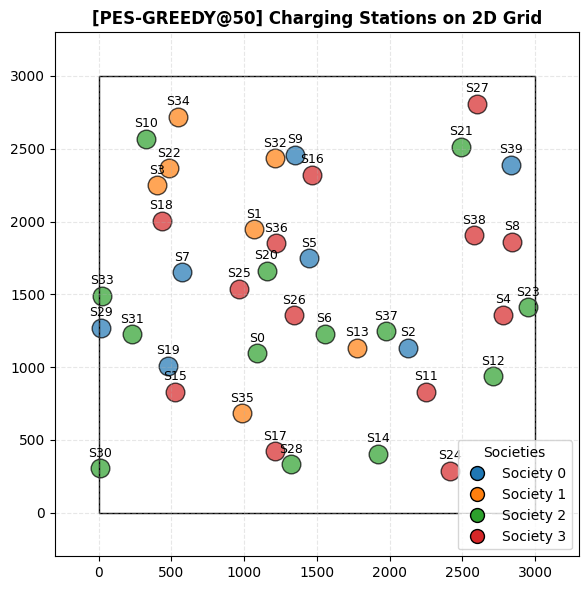

In [20]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=300)

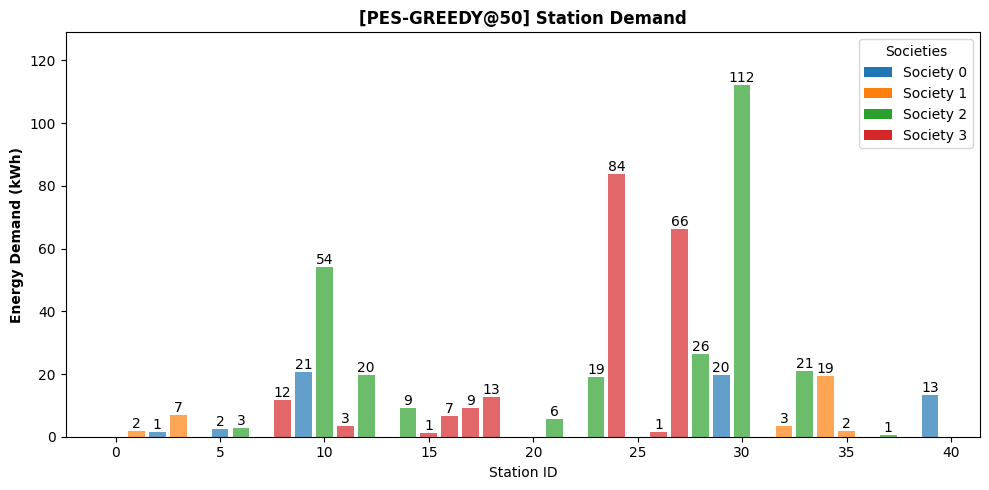

In [21]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

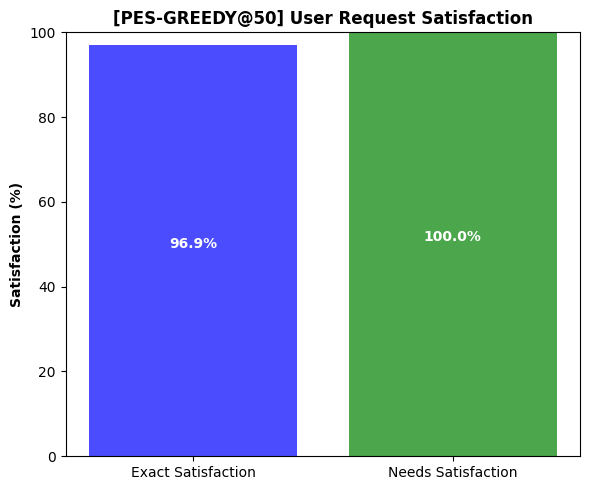

In [22]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

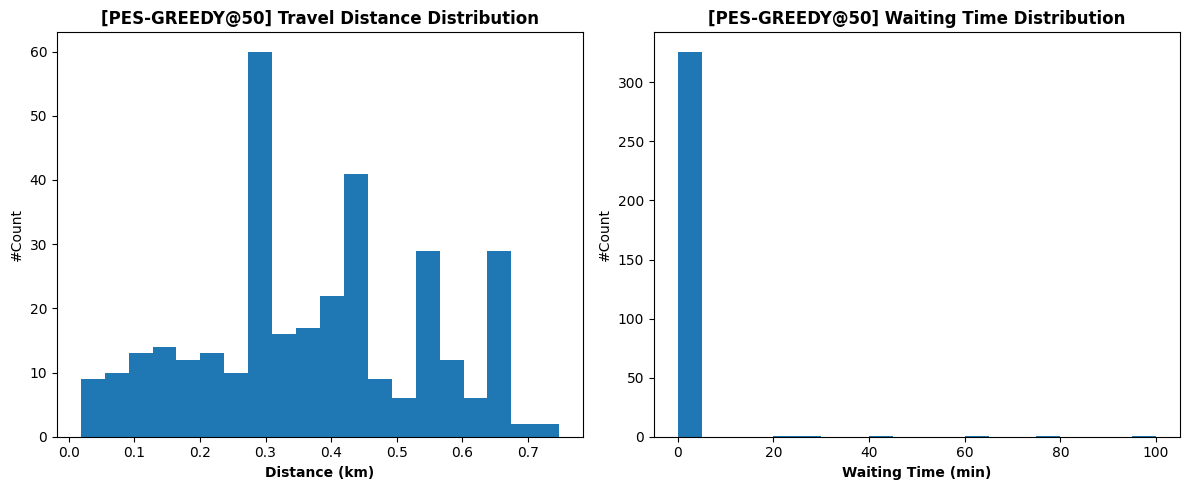

In [23]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

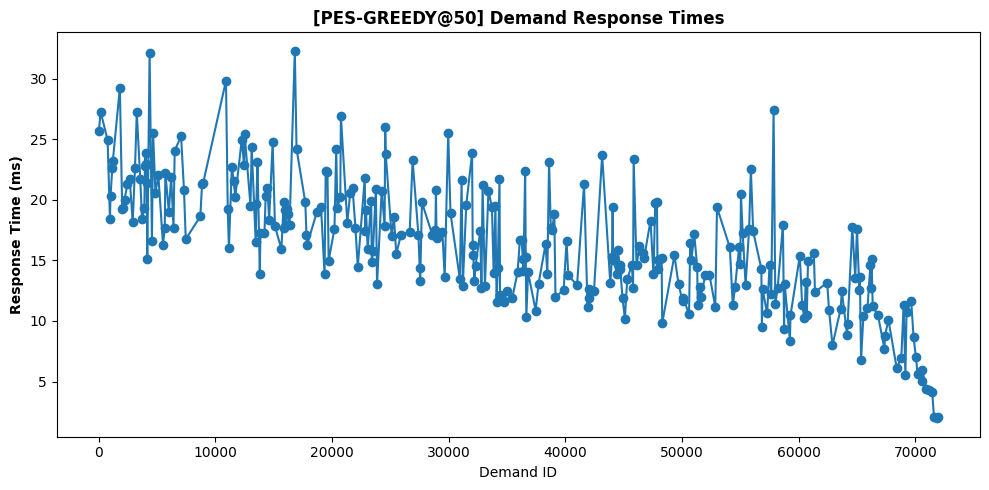

In [24]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

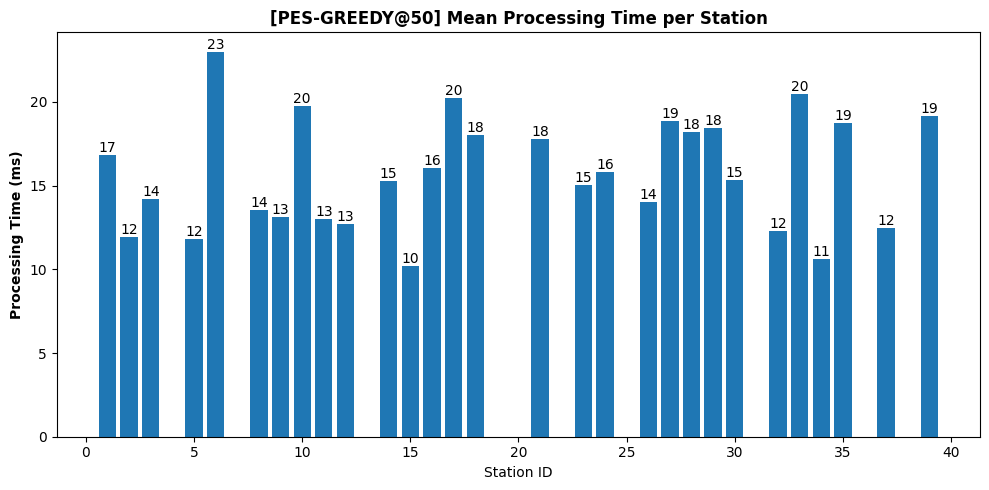

In [25]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [26]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [27]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


57

##### *Run*

In [28]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:17:13.748 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:17:13.878 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:17:15.187 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:17:15.818 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:17:16.440 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:17:16.547 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:17:16.775 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:17:17.866 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:17:18.083 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:17:18.967 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:17:19.489 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [29]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 3.50 kWh
  Station 1: 34.17 kWh
  Station 2: 12.47 kWh
  Station 3: 21.09 kWh
  Station 4: 0.00 kWh
  Station 5: 0.00 kWh
  Station 6: 16.80 kWh
  Station 7: 30.58 kWh
  Station 8: 2.10 kWh
  Station 9: 60.10 kWh
  Station 10: 14.99 kWh
  Station 11: 8.10 kWh
  Station 12: 0.00 kWh
  Station 13: 0.00 kWh
  Station 14: 1.73 kWh
  Station 15: 14.12 kWh
  Station 16: 17.99 kWh
  Station 17: 17.68 kWh
  Station 18: 4.03 kWh
  Station 19: 64.56 kWh
  Station 20: 69.79 kWh
  Station 21: 5.32 kWh
  Station 22: 4.14 kWh
  Station 23: 29.44 kWh
  Station 24: 15.29 kWh
  Station 25: 21.52 kWh
  Station 26: 4.06 kWh
  Station 27: 0.00 kWh
  Station 28: 18.62 kWh
  Station 29: 2.30 kWh
  Station 30: 3.35 kWh
  Station 31: 9.77 kWh
  Station 32: 11.75 kWh
  Station 33: 11.39 kWh
  Station 34: 0.00 kWh
  Station 35: 5.58 kWh
  Station 36: 1.17 kWh
  Station 37: 5.00 kWh
  Station 38: 2.95 kWh
  Station 39: 4.08 kWh

--- User

In [30]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

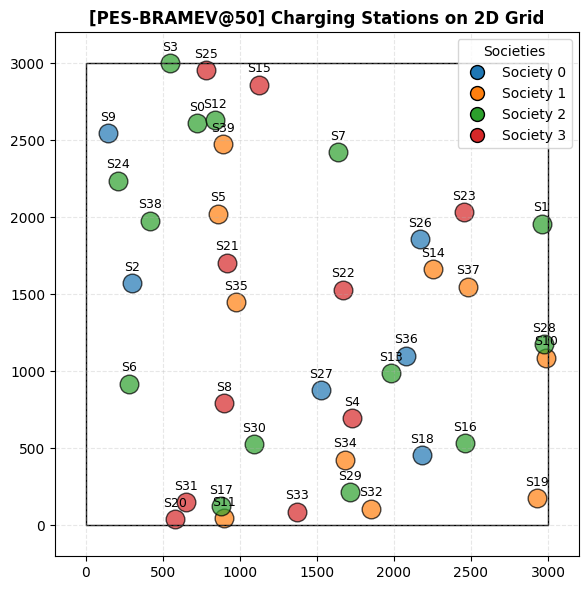

In [31]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

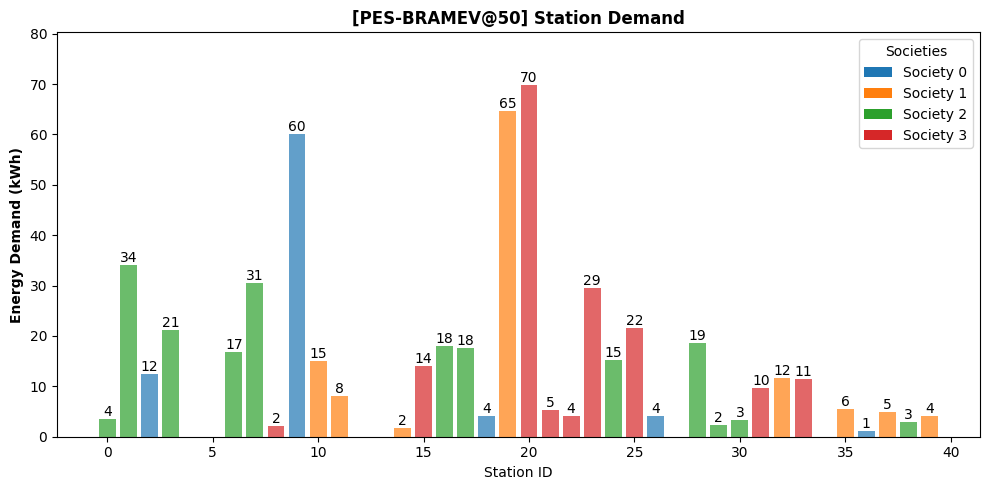

In [32]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

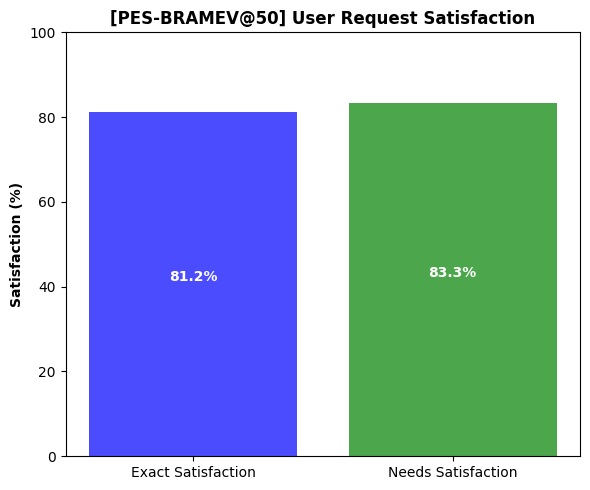

In [33]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

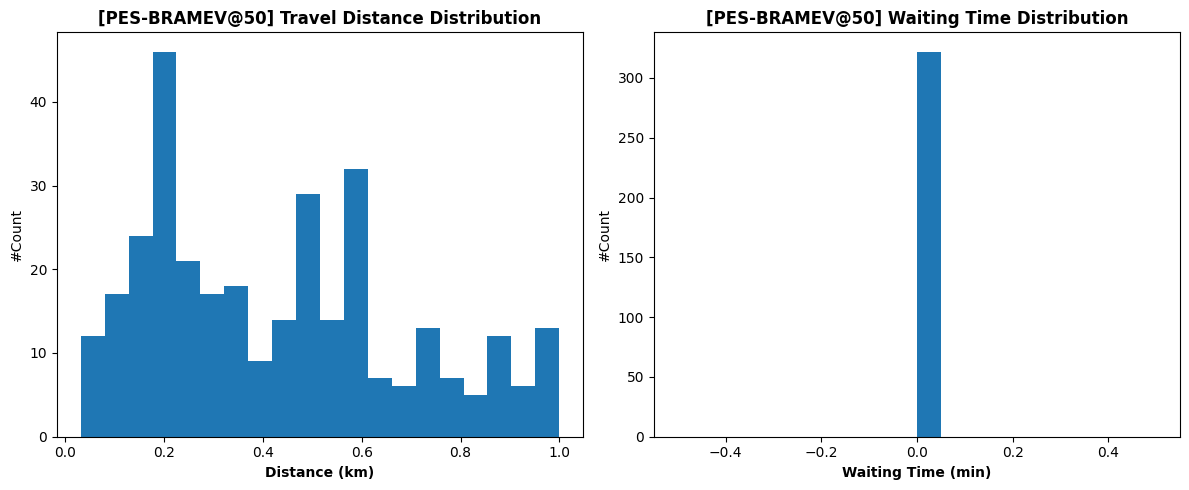

In [34]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

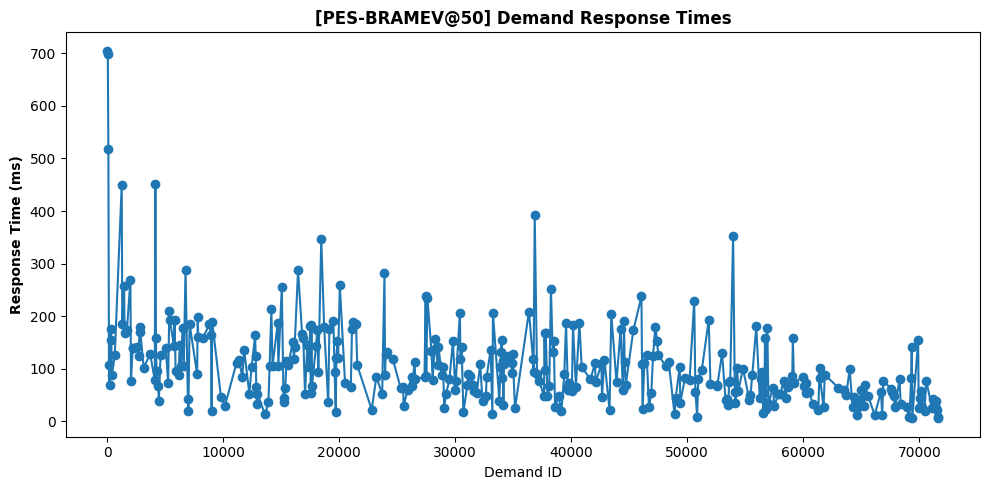

In [35]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

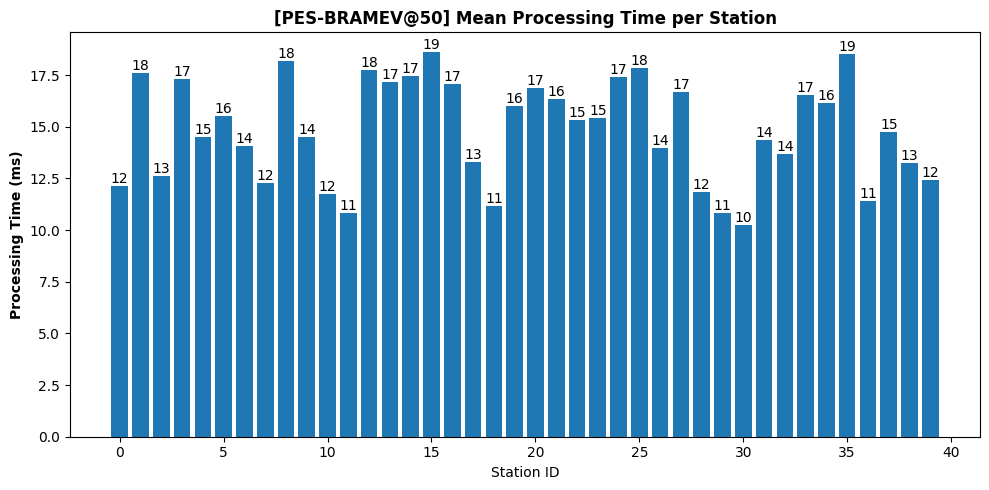

In [36]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

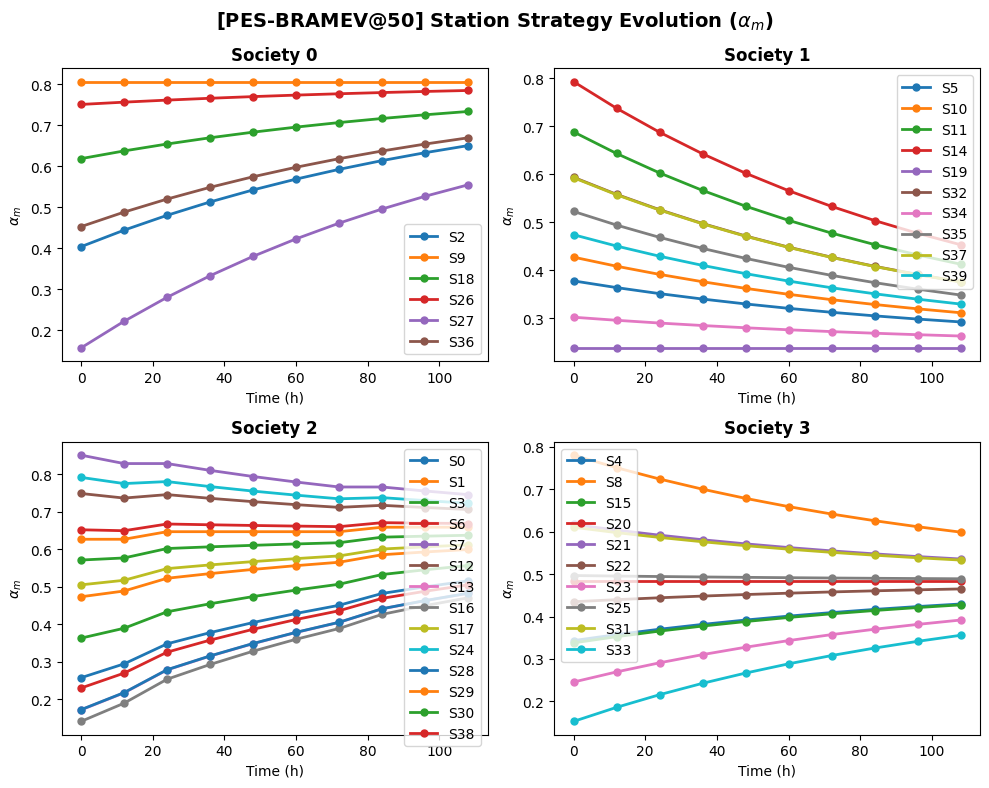

In [37]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [38]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           2  0.164583  0.038889  0.000000  0.000000       NaN   
1            0           9  0.472222  0.264583  0.043750  0.000000  0.122917   
2            0          18  0.051389  0.000000  0.000000  0.000000       NaN   
3            0          26  0.051389  0.000000  0.000000  0.000000  0.000000   
4            0          27  0.000000  0.000000  0.000000  0.000000  0.000000   
5            0          36  0.013889  0.000000  0.000000  0.000000       NaN   
6            1           5  0.000000  0.000000  0.000000  0.000000  0.000000   
7            1          10  0.222917  0.016667  0.000000  0.000000       NaN   
8            1          11  0.116667  0.000000  0.000000  0.000000       NaN   
9            1          14  0.036111  0.000000  0.000000  0.000000  0.000000   
10           1          19  0.404167  0.309722  0.065278  0.000000  0.000000   
11           1          32  0.137500  0.

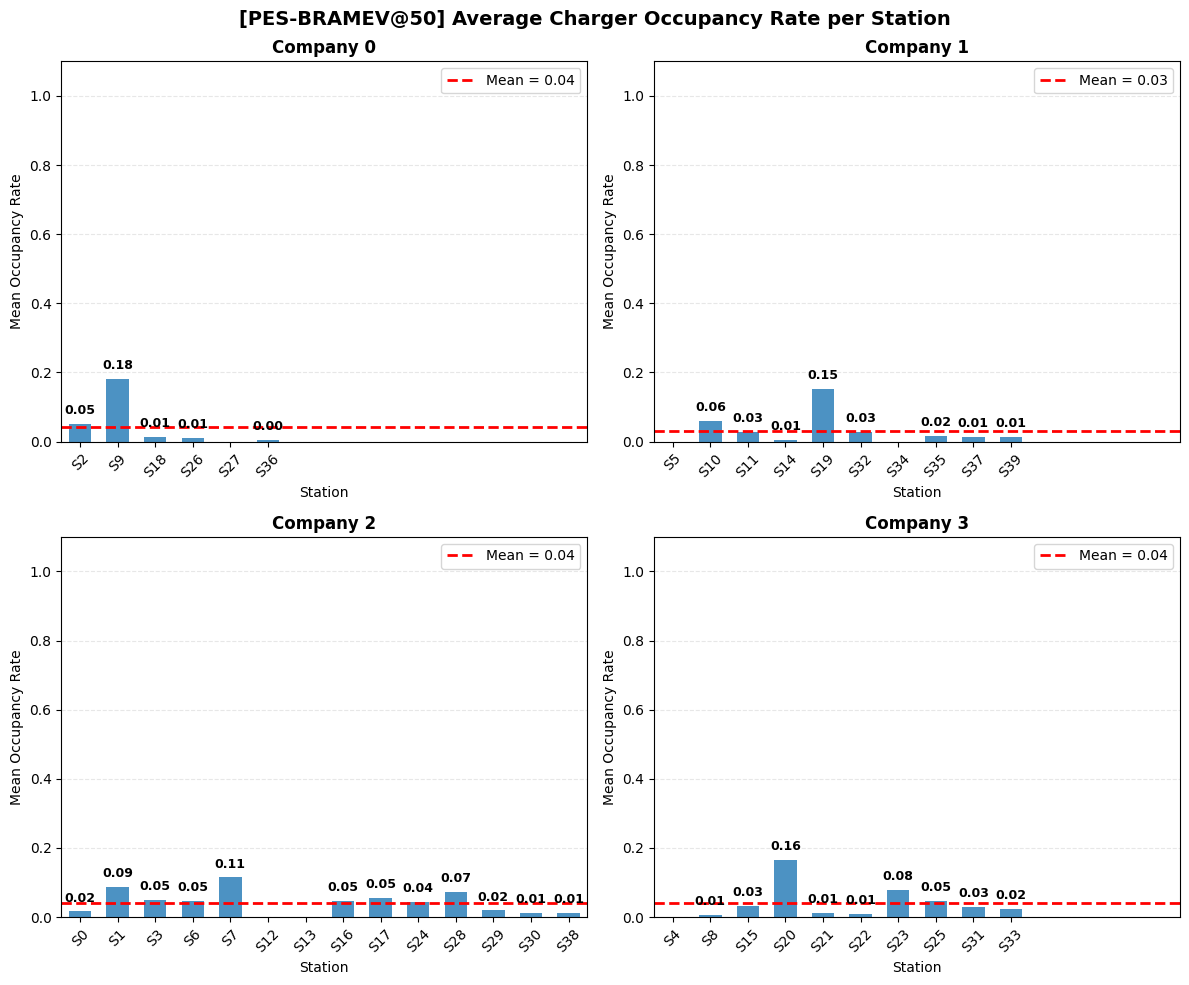

In [39]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

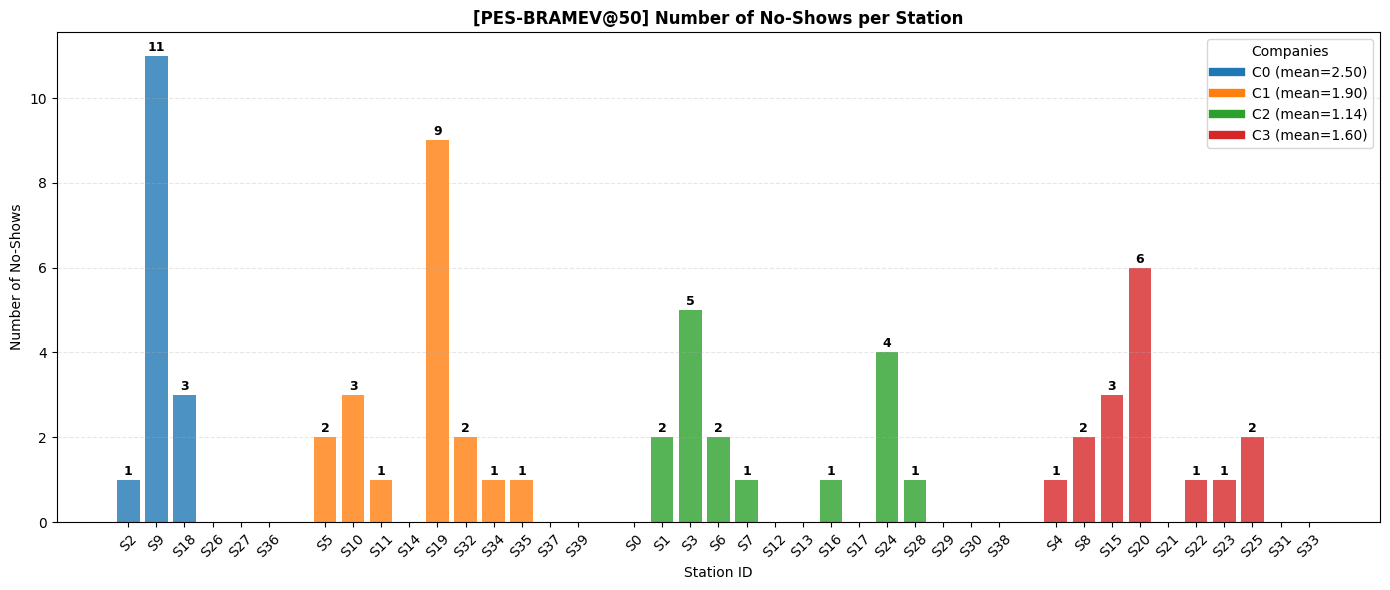

In [40]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [41]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,2,8,7,1,0,0,0.875000,0.125000,0.0,0.0
1,0,9,46,35,11,0,0,0.760870,0.239130,0.0,0.0
2,0,18,5,2,3,0,0,0.400000,0.600000,0.0,0.0
3,0,26,3,3,0,0,0,1.000000,0.000000,0.0,0.0
4,0,27,0,0,0,0,0,NaN,NaN,NaN,NaN
5,0,36,1,1,0,0,0,1.000000,0.000000,0.0,0.0
6,1,5,2,0,2,0,0,0.000000,1.000000,0.0,0.0
7,1,10,11,8,3,0,0,0.727273,0.272727,0.0,0.0
8,1,11,7,5,1,0,0,0.714286,0.142857,0.0,0.0
9,1,14,1,1,0,0,0,1.000000,0.000000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [42]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

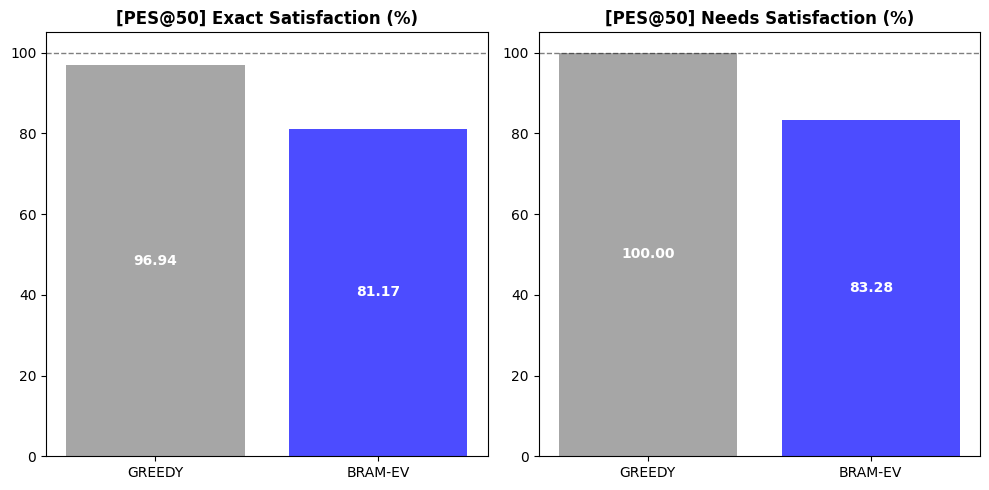

In [43]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

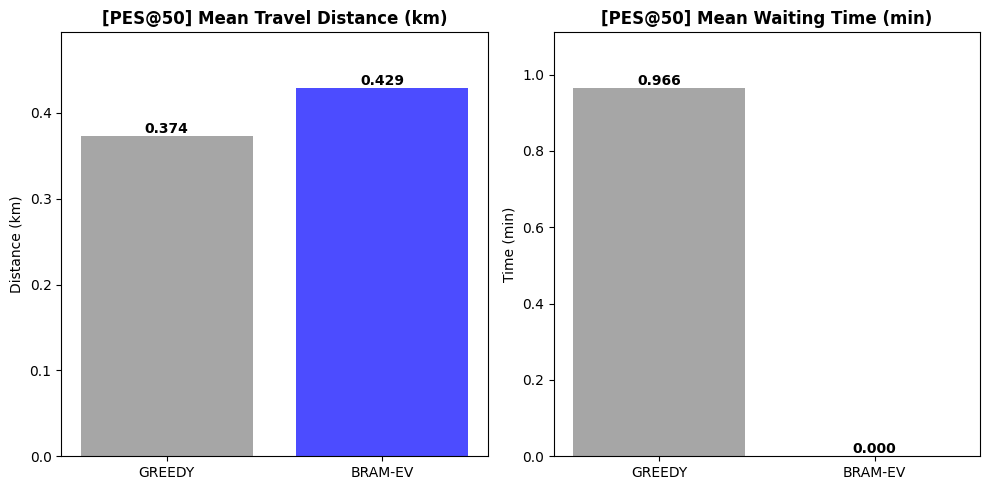

In [44]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

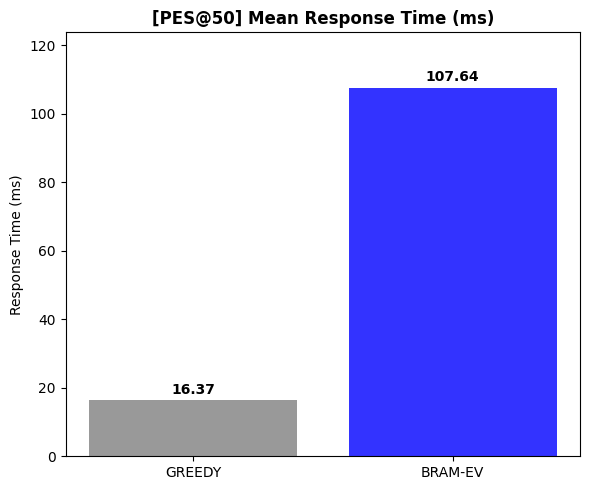

In [45]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@100cars**

#### **CONFIG**

In [46]:
nb_car = 100
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [47]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/100cars


##### *Initialisation*

In [48]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [49]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:17:51.030 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:17:51.232 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:17:51.350 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:17:51.499 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:17:51.676 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:17:51.882 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:17:51.950 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:17:52.058 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:17:52.214 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:17:52.317 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:17:52.491 | IN

##### *Metrics*

In [50]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 0.00 kWh
  Station 1: 35.57 kWh
  Station 2: 8.00 kWh
  Station 3: 180.96 kWh
  Station 4: 1.60 kWh
  Station 5: 4.85 kWh
  Station 6: 28.02 kWh
  Station 7: 7.52 kWh
  Station 8: 4.85 kWh
  Station 9: 3.33 kWh
  Station 10: 52.27 kWh
  Station 11: 11.43 kWh
  Station 12: 2.12 kWh
  Station 13: 9.59 kWh
  Station 14: 2.80 kWh
  Station 15: 0.00 kWh
  Station 16: 141.97 kWh
  Station 17: 3.08 kWh
  Station 18: 10.47 kWh
  Station 19: 2.16 kWh
  Station 20: 131.68 kWh
  Station 21: 72.86 kWh
  Station 22: 2.95 kWh
  Station 23: 3.25 kWh
  Station 24: 59.02 kWh
  Station 25: 27.75 kWh
  Station 26: 42.38 kWh
  Station 27: 0.89 kWh
  Station 28: 4.30 kWh
  Station 29: 15.26 kWh
  Station 30: 2.58 kWh
  Station 31: 159.84 kWh
  Station 32: 18.23 kWh
  Station 33: 1.65 kWh
  Station 34: 9.06 kWh
  Station 35: 0.00 kWh
  Station 36: 18.51 kWh
  Station 37: 30.81 kWh
  Station 38: 1.33 kWh
  Station 39: 0.00 kWh

--- U

In [51]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

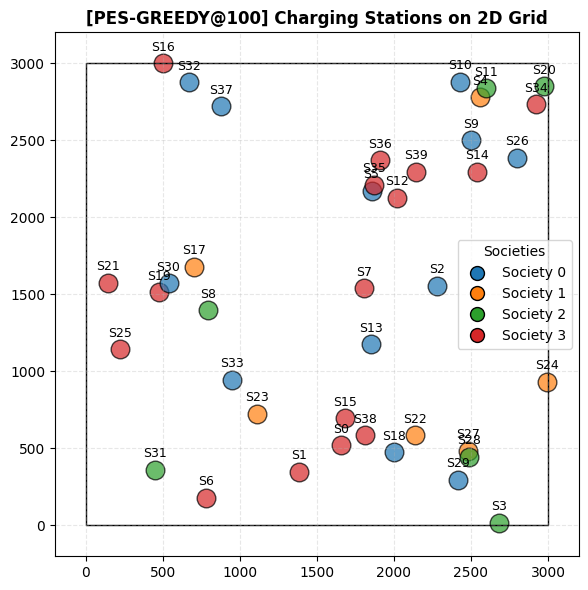

In [52]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

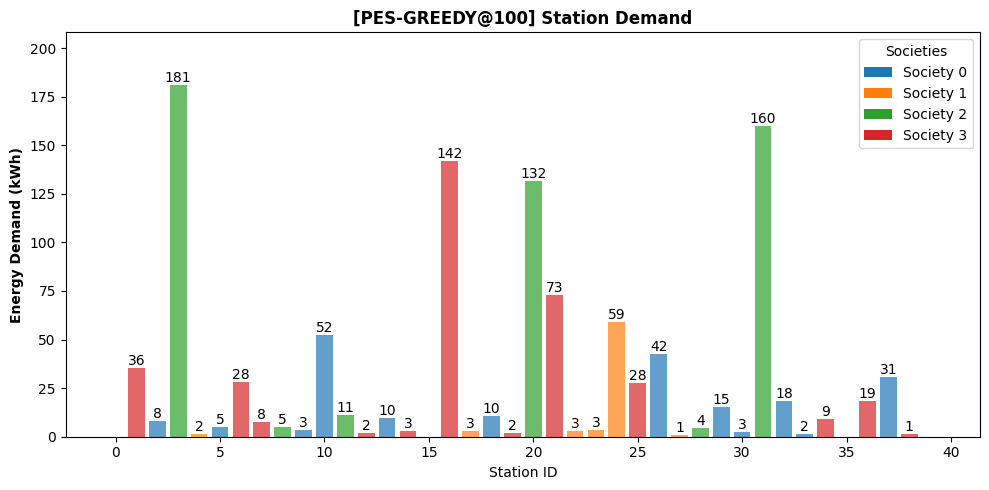

In [53]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

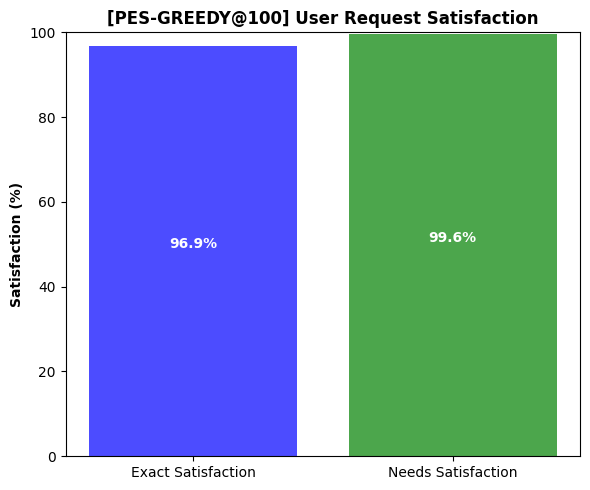

In [54]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

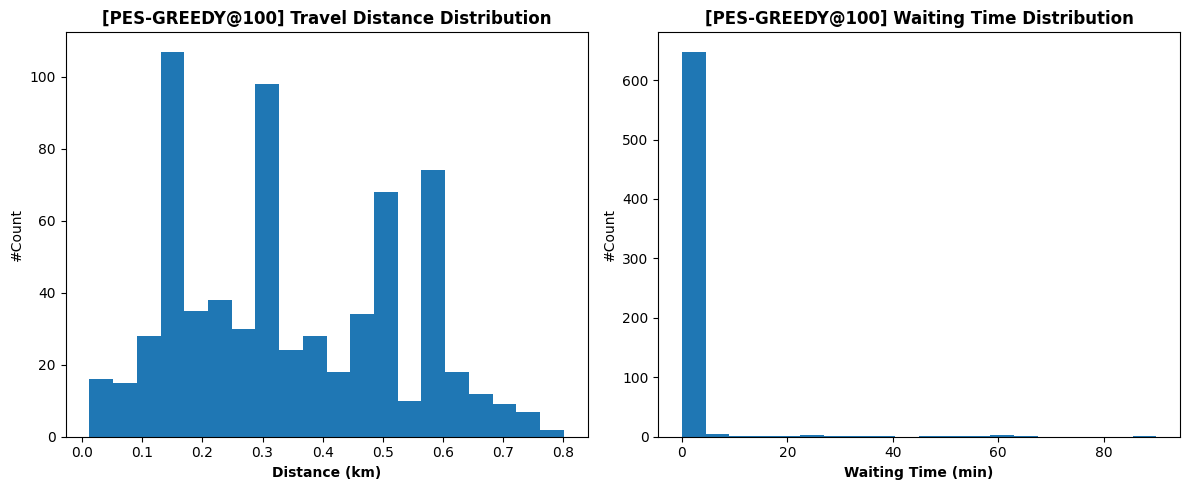

In [55]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

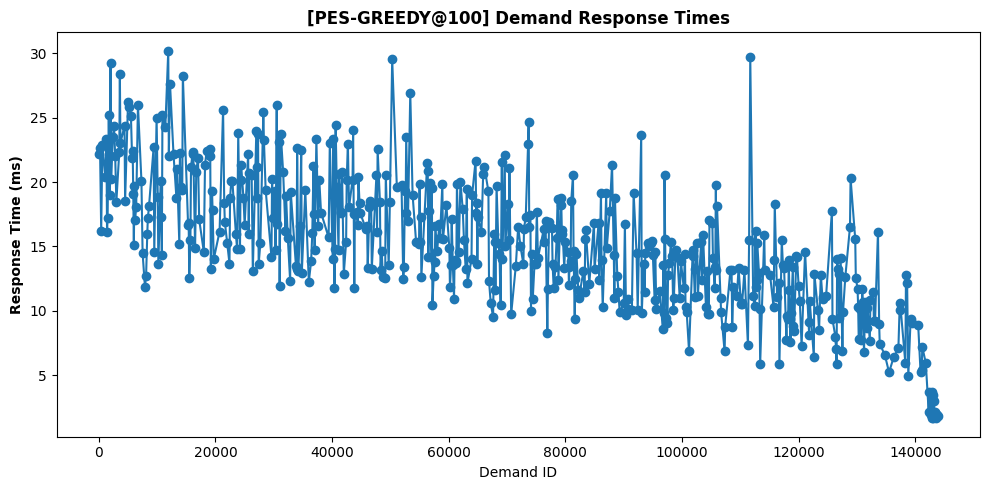

In [56]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

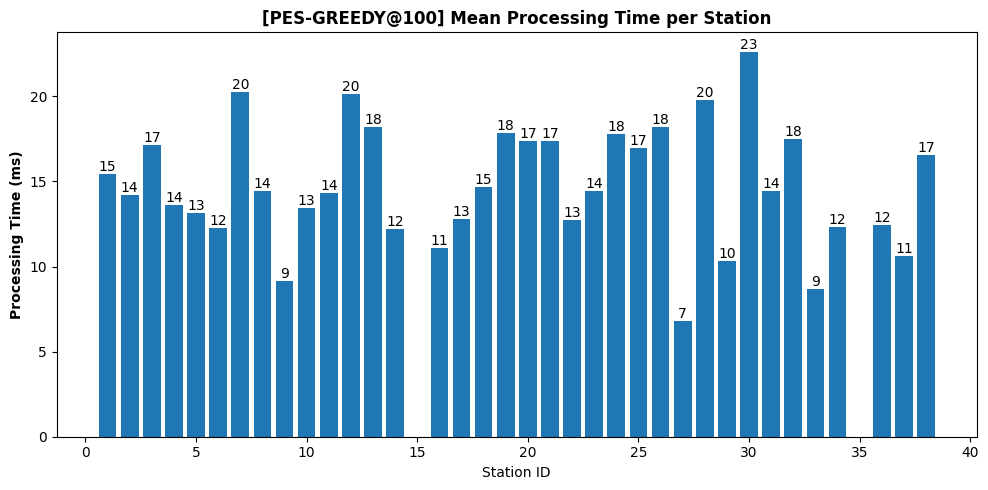

In [57]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [58]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [59]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [60]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:18:03.991 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:18:04.429 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:18:05.470 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:18:06.382 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:18:07.895 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:18:09.351 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:18:10.094 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:18:11.016 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:18:11.992 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:18:13.262 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:18:14.661 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [61]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 27.87 kWh
  Station 1: 98.81 kWh
  Station 2: 27.62 kWh
  Station 3: 11.03 kWh
  Station 4: 0.00 kWh
  Station 5: 10.38 kWh
  Station 6: 39.04 kWh
  Station 7: 13.85 kWh
  Station 8: 24.47 kWh
  Station 9: 1.47 kWh
  Station 10: 37.84 kWh
  Station 11: 17.25 kWh
  Station 12: 3.33 kWh
  Station 13: 65.91 kWh
  Station 14: 10.01 kWh
  Station 15: 97.37 kWh
  Station 16: 10.43 kWh
  Station 17: 0.95 kWh
  Station 18: 17.51 kWh
  Station 19: 47.92 kWh
  Station 20: 18.37 kWh
  Station 21: 10.28 kWh
  Station 22: 14.00 kWh
  Station 23: 22.75 kWh
  Station 24: 99.27 kWh
  Station 25: 13.14 kWh
  Station 26: 7.73 kWh
  Station 27: 32.56 kWh
  Station 28: 5.41 kWh
  Station 29: 15.44 kWh
  Station 30: 40.96 kWh
  Station 31: 57.23 kWh
  Station 32: 7.48 kWh
  Station 33: 93.77 kWh
  Station 34: 5.53 kWh
  Station 35: 29.45 kWh
  Station 36: 2.63 kWh
  Station 37: 18.25 kWh
  Station 38: 4.59 kWh
  Station 39: 7.47 kW

In [62]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

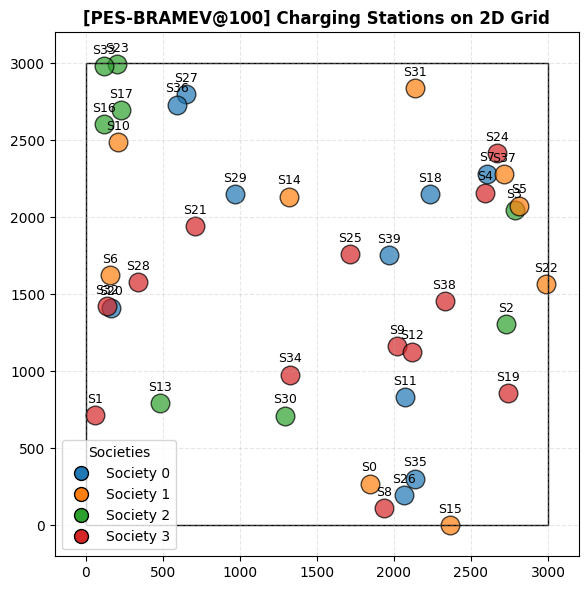

In [63]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

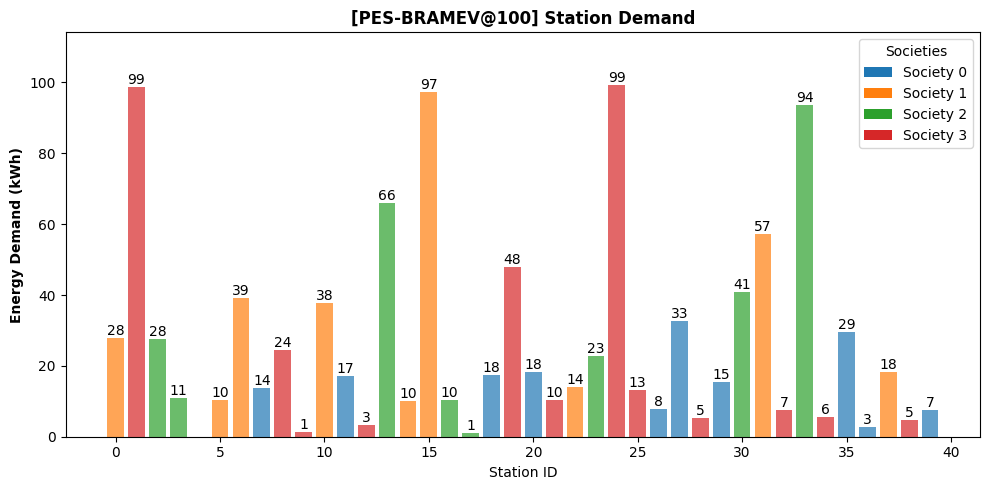

In [64]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

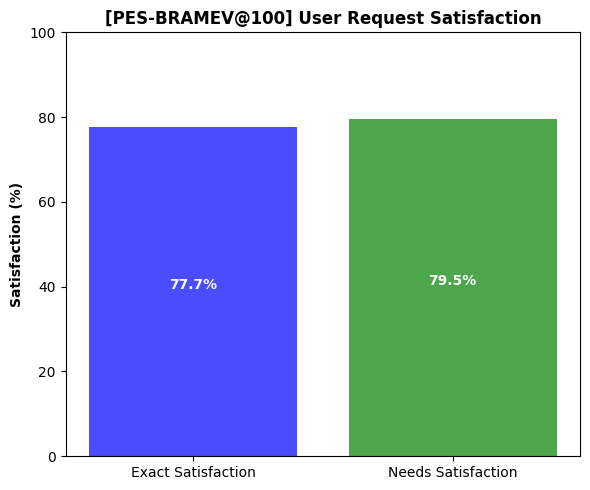

In [65]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

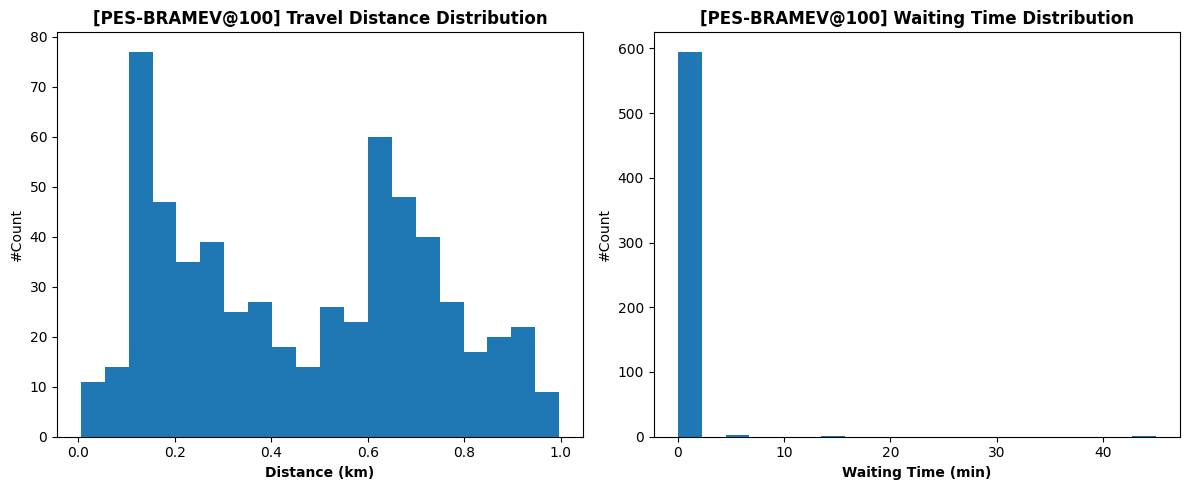

In [66]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

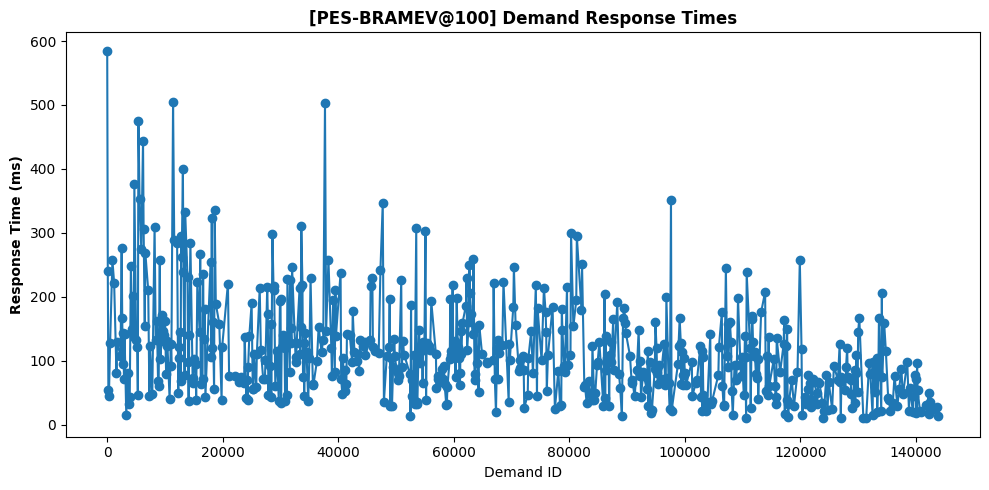

In [67]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

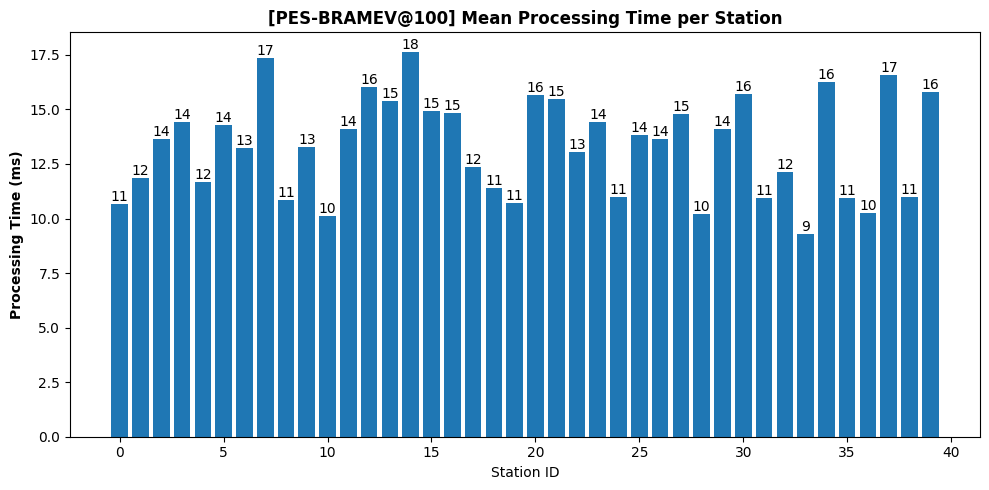

In [68]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

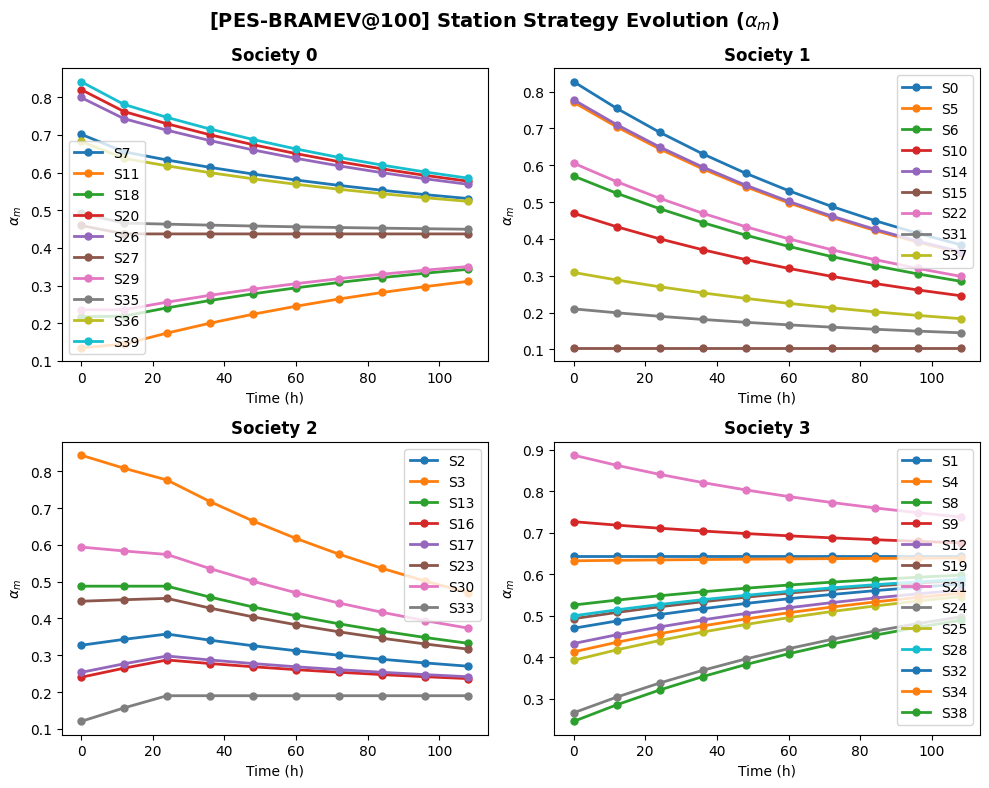

In [69]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [70]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           7  0.130556  0.000000  0.000000  0.000000  0.000000   
1            0          11  0.131944  0.083333  0.000000  0.000000  0.000000   
2            0          18  0.172222  0.065972  0.000000  0.000000       NaN   
3            0          20  0.154861  0.018056  0.021528  0.000000  0.000000   
4            0          26  0.112500  0.000000  0.000000  0.000000  0.000000   
5            0          27  0.308333  0.098611  0.000000  0.000000  0.000000   
6            0          29  0.195139  0.021528  0.000000  0.000000  0.000000   
7            0          35  0.318056  0.032639  0.000000  0.033333       NaN   
8            0          36  0.030556  0.000000  0.000000  0.000000       NaN   
9            0          39  0.080556  0.000000  0.000000  0.000000  0.000000   
10           1           0  0.272917  0.097222  0.000000  0.053472       NaN   
11           1           5  0.137500  0.

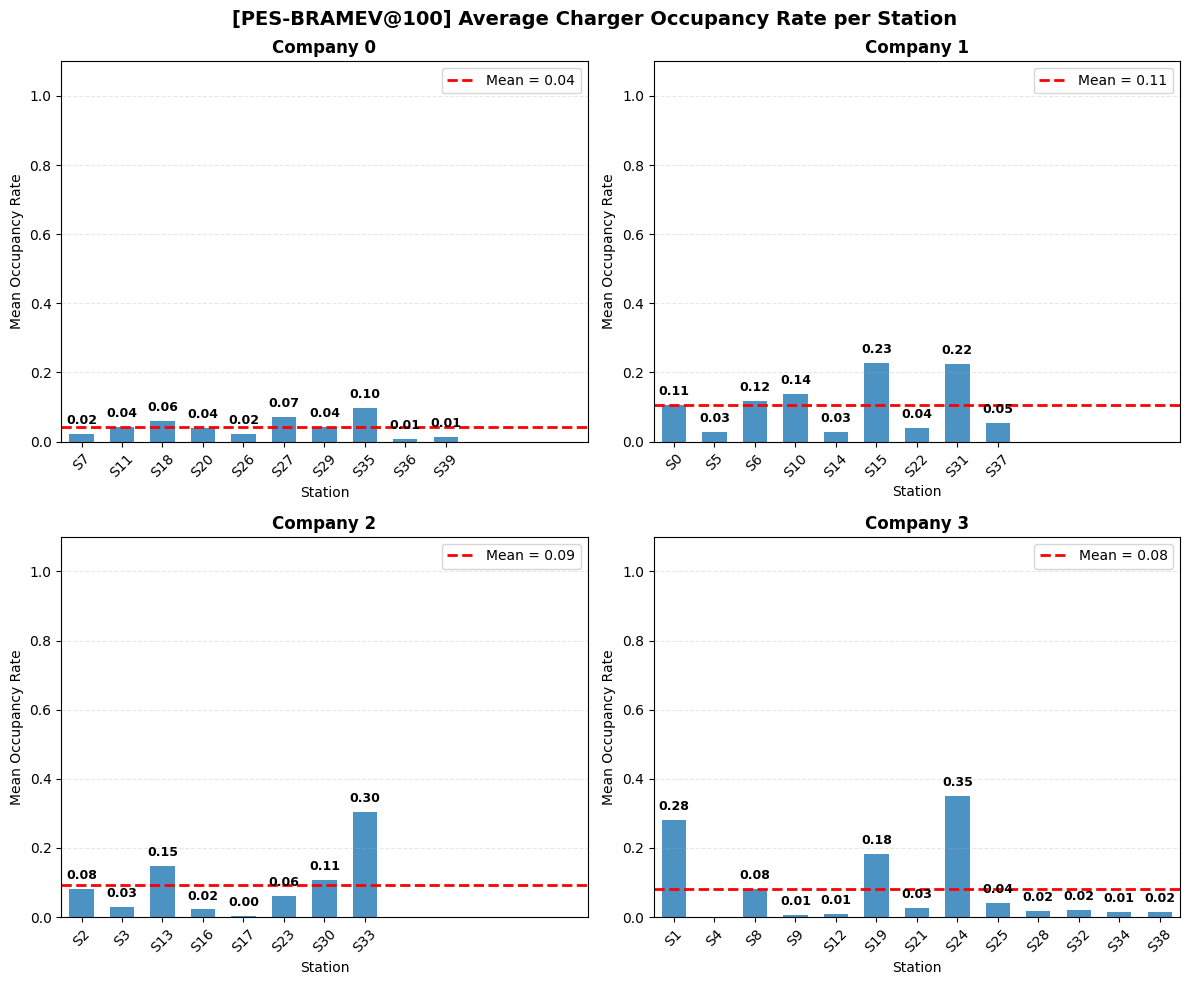

In [71]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

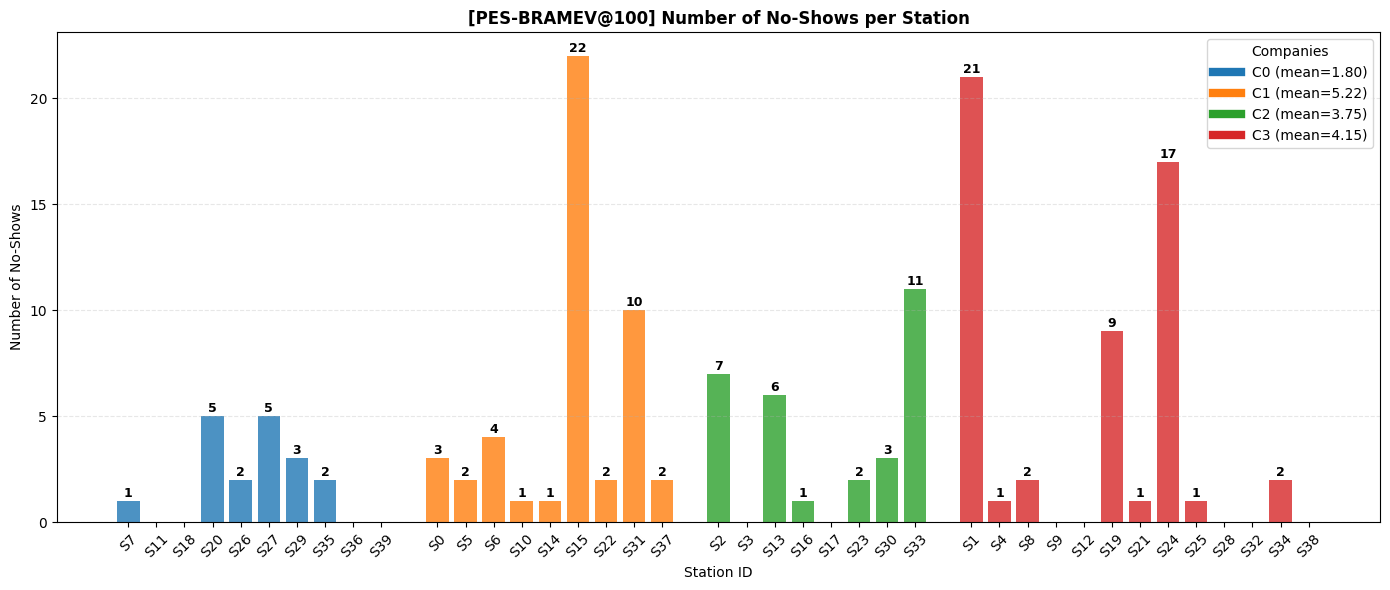

In [72]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [73]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,7,9,8,1,0,0,0.888889,0.111111,0.0,0.0
1,0,11,9,9,0,0,0,1.000000,0.000000,0.0,0.0
2,0,18,11,10,0,0,0,0.909091,0.000000,0.0,0.0
3,0,20,16,11,5,0,0,0.687500,0.312500,0.0,0.0
4,0,26,6,4,2,0,0,0.666667,0.333333,0.0,0.0
5,0,27,22,17,5,0,0,0.772727,0.227273,0.0,0.0
6,0,29,12,8,3,0,0,0.666667,0.250000,0.0,0.0
7,0,35,18,16,2,0,0,0.888889,0.111111,0.0,0.0
8,0,36,2,2,0,0,0,1.000000,0.000000,0.0,0.0
9,0,39,4,4,0,0,0,1.000000,0.000000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [74]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

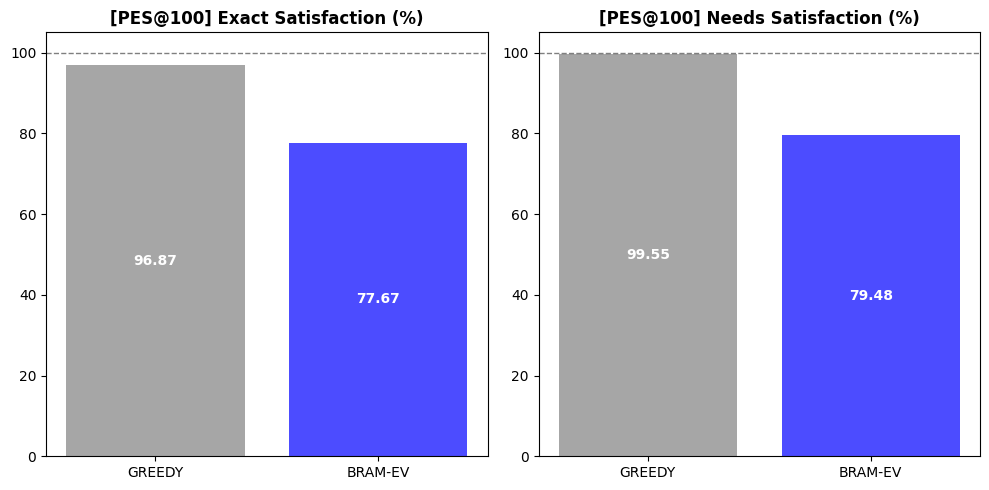

In [75]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

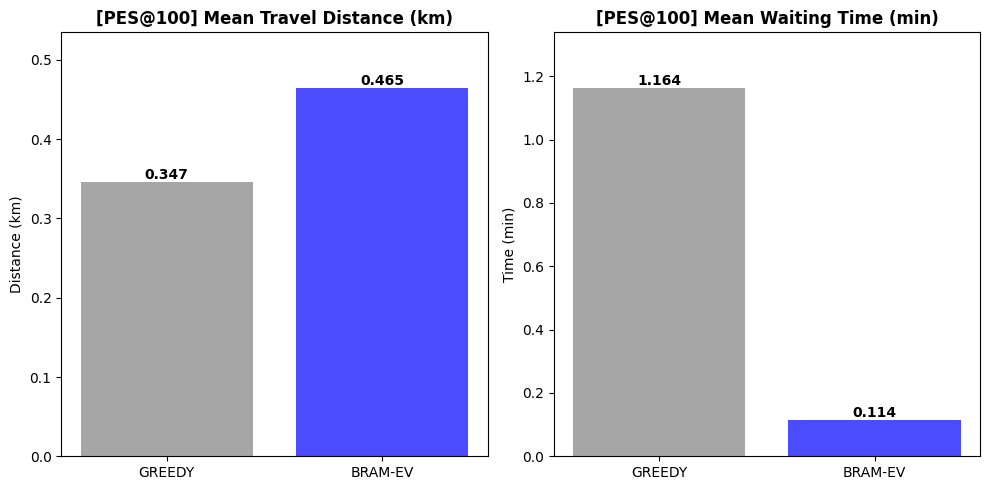

In [76]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

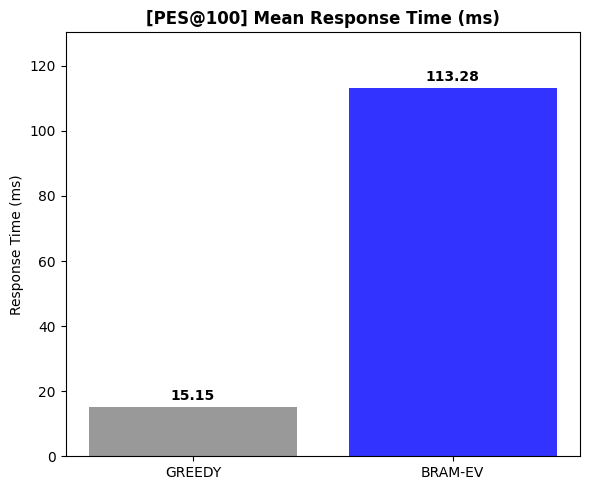

In [77]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@150cars**

#### **CONFIG**

In [78]:
nb_car = 150
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [79]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/150cars


##### *Initialisation*

In [80]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [81]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:19:21.430 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:19:21.618 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:19:21.761 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:19:22.041 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:19:22.282 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:19:22.400 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:19:22.510 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:19:22.666 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:19:22.918 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:19:23.295 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:19:23.525 | IN

##### *Metrics*

In [82]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 156.83 kWh
  Station 1: 4.06 kWh
  Station 2: 208.53 kWh
  Station 3: 214.45 kWh
  Station 4: 3.85 kWh
  Station 5: 44.50 kWh
  Station 6: 13.43 kWh
  Station 7: 12.36 kWh
  Station 8: 6.03 kWh
  Station 9: 6.33 kWh
  Station 10: 11.47 kWh
  Station 11: 19.84 kWh
  Station 12: 24.68 kWh
  Station 13: 49.15 kWh
  Station 14: 0.00 kWh
  Station 15: 89.92 kWh
  Station 16: 4.65 kWh
  Station 17: 14.65 kWh
  Station 18: 9.54 kWh
  Station 19: 3.72 kWh
  Station 20: 46.07 kWh
  Station 21: 3.74 kWh
  Station 22: 65.15 kWh
  Station 23: 7.74 kWh
  Station 24: 6.70 kWh
  Station 25: 13.47 kWh
  Station 26: 1.87 kWh
  Station 27: 6.83 kWh
  Station 28: 48.27 kWh
  Station 29: 183.43 kWh
  Station 30: 73.40 kWh
  Station 31: 53.89 kWh
  Station 32: 31.62 kWh
  Station 33: 54.19 kWh
  Station 34: 3.39 kWh
  Station 35: 3.49 kWh
  Station 36: 88.97 kWh
  Station 37: 31.17 kWh
  Station 38: 8.35 kWh
  Station 39: 35.79 kWh

In [83]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

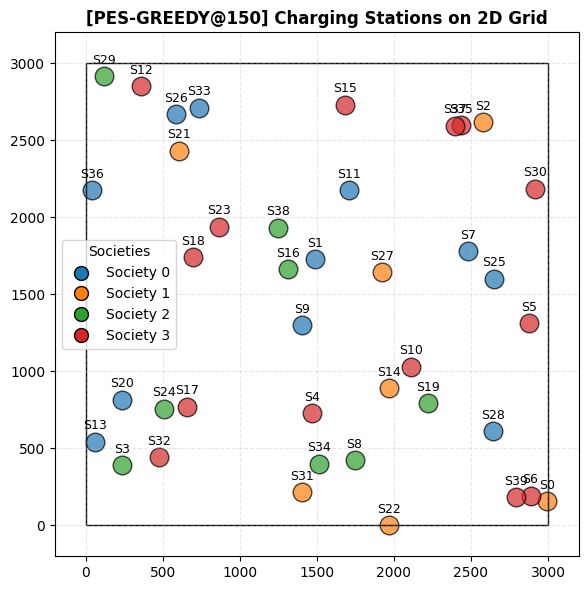

In [84]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

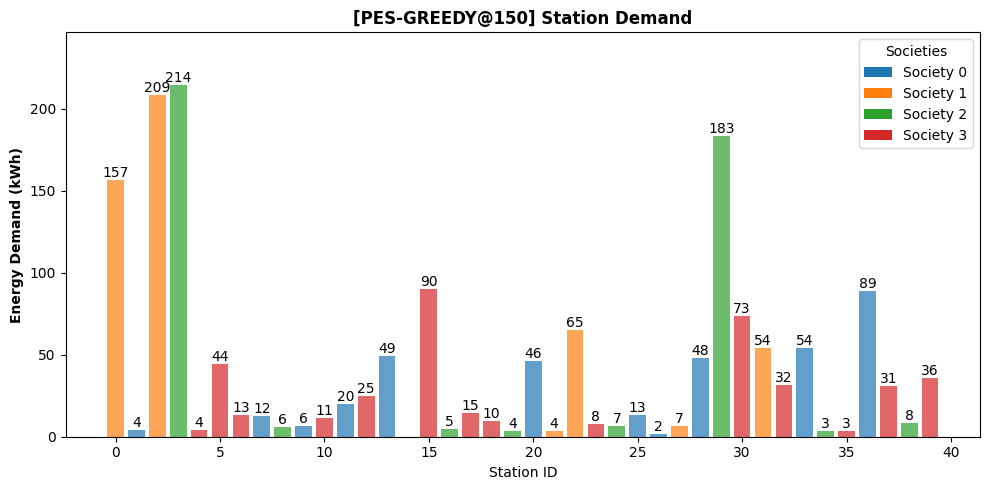

In [85]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

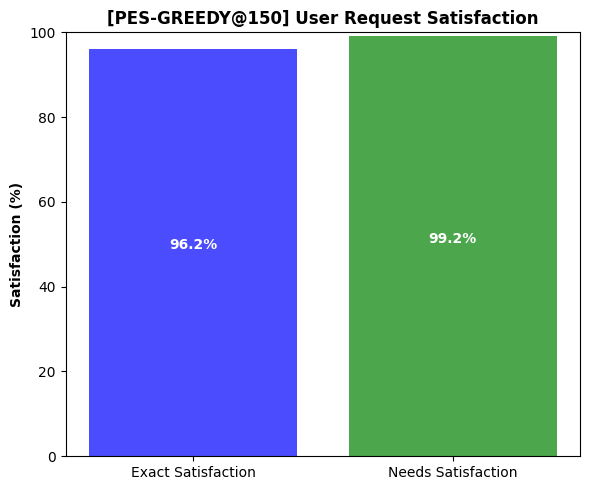

In [86]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

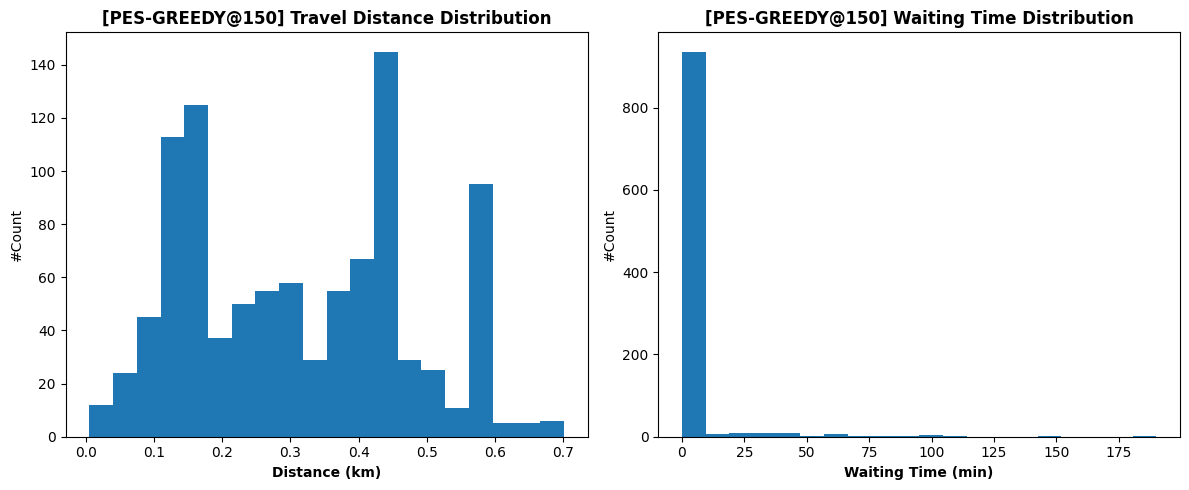

In [87]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

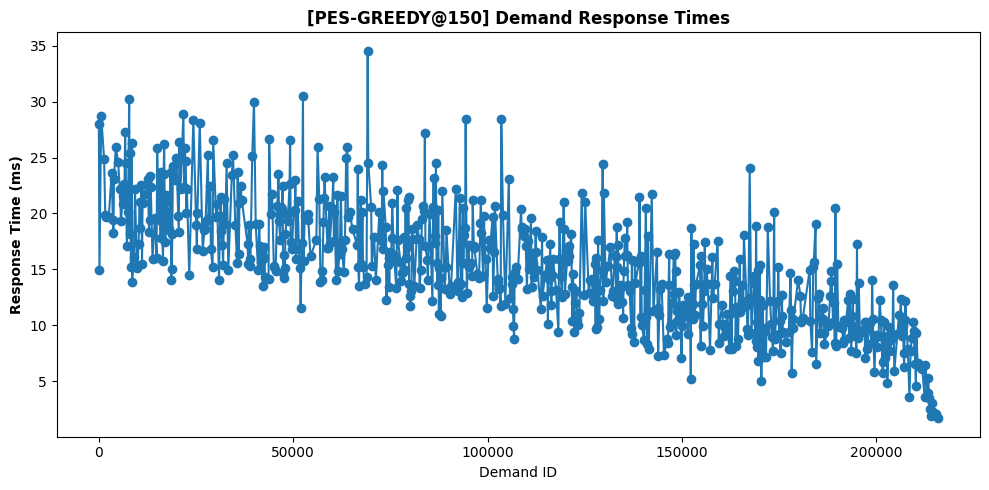

In [88]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

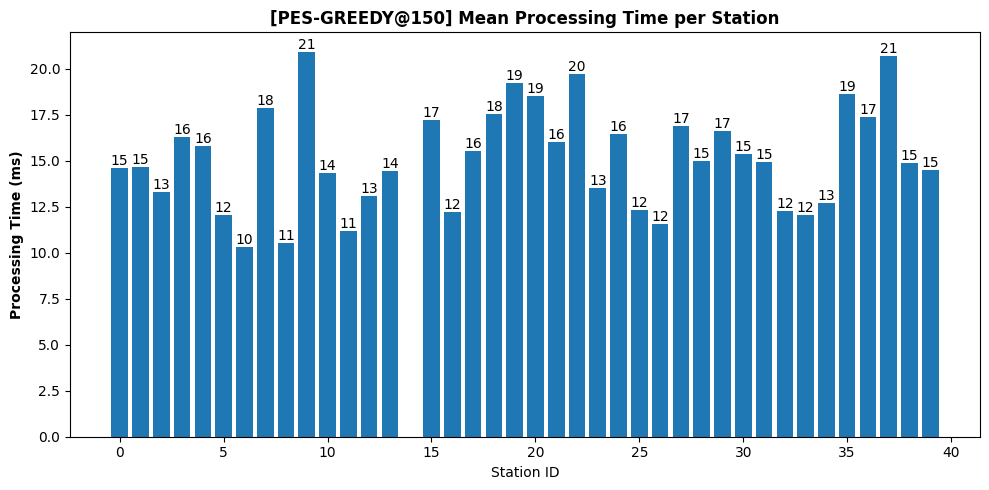

In [89]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [90]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [91]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [92]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:19:45.636 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:19:47.611 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:19:48.930 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:19:50.570 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:19:51.952 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:19:52.839 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:19:54.993 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:19:56.248 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:19:57.829 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:19:59.290 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:20:00.932 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [93]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 10.48 kWh
  Station 1: 30.96 kWh
  Station 2: 95.15 kWh
  Station 3: 27.47 kWh
  Station 4: 51.77 kWh
  Station 5: 13.88 kWh
  Station 6: 14.61 kWh
  Station 7: 73.51 kWh
  Station 8: 8.71 kWh
  Station 9: 12.59 kWh
  Station 10: 134.18 kWh
  Station 11: 53.87 kWh
  Station 12: 36.86 kWh
  Station 13: 71.82 kWh
  Station 14: 43.61 kWh
  Station 15: 10.03 kWh
  Station 16: 2.49 kWh
  Station 17: 23.09 kWh
  Station 18: 40.52 kWh
  Station 19: 144.50 kWh
  Station 20: 3.90 kWh
  Station 21: 59.55 kWh
  Station 22: 131.50 kWh
  Station 23: 55.47 kWh
  Station 24: 10.73 kWh
  Station 25: 34.38 kWh
  Station 26: 60.87 kWh
  Station 27: 46.02 kWh
  Station 28: 11.73 kWh
  Station 29: 5.81 kWh
  Station 30: 2.39 kWh
  Station 31: 13.19 kWh
  Station 32: 7.44 kWh
  Station 33: 56.95 kWh
  Station 34: 12.06 kWh
  Station 35: 16.68 kWh
  Station 36: 138.23 kWh
  Station 37: 25.82 kWh
  Station 38: 4.20 kWh
  Station 39: 

In [94]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

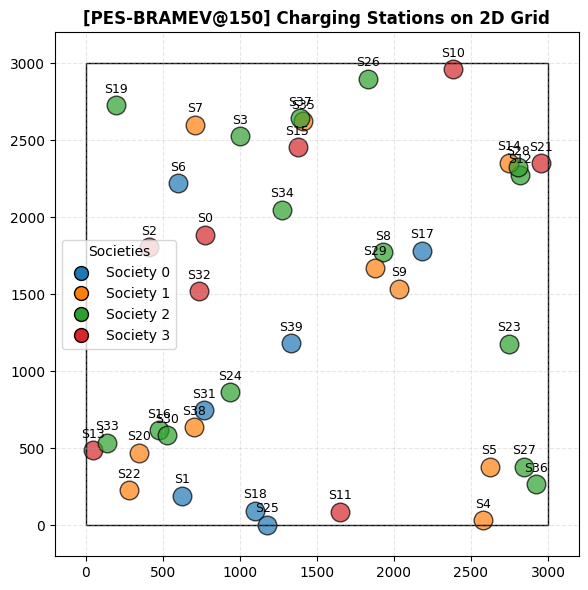

In [95]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

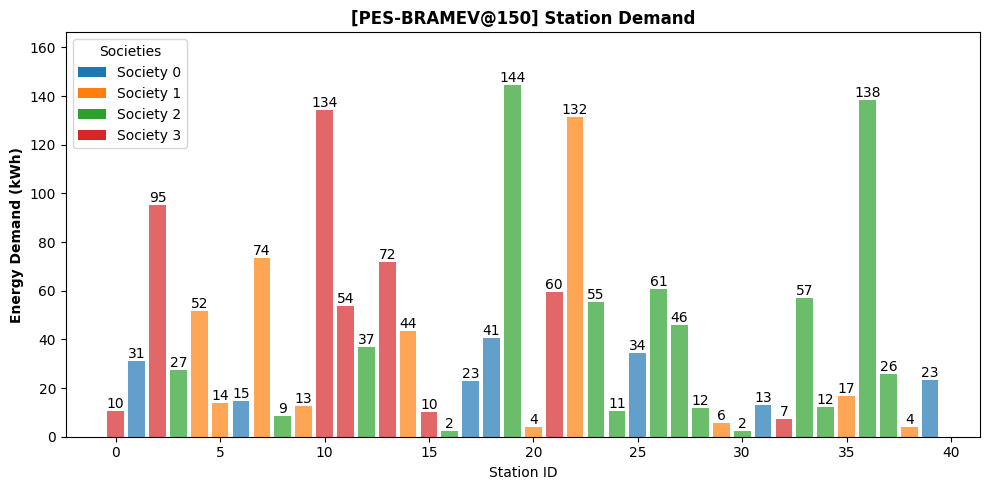

In [96]:
plot_station_demand(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, societies=societies, figsize=(10, 5))

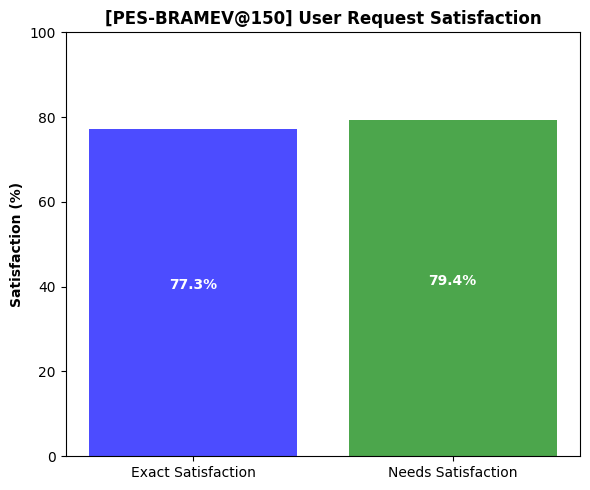

In [97]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

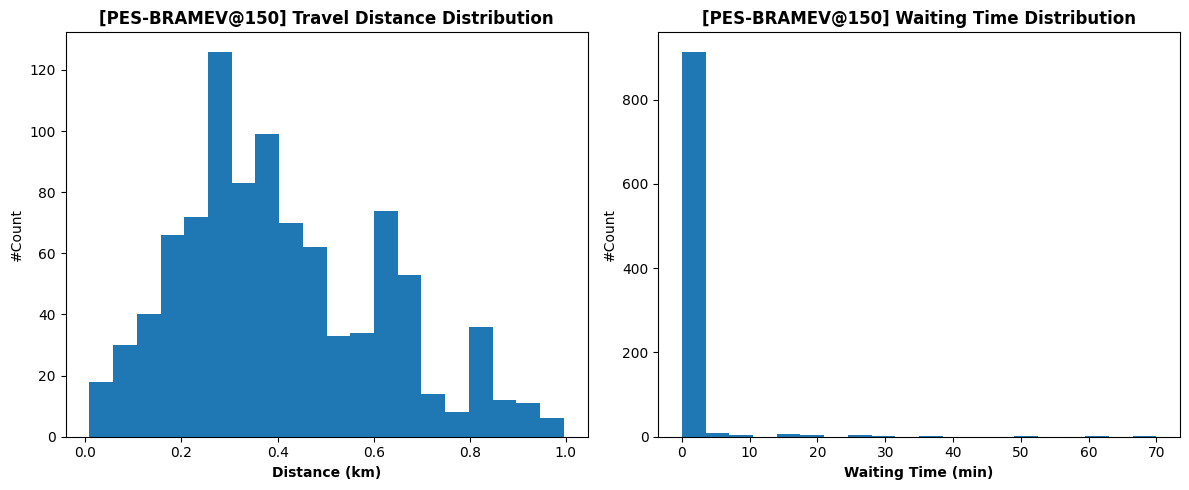

In [98]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

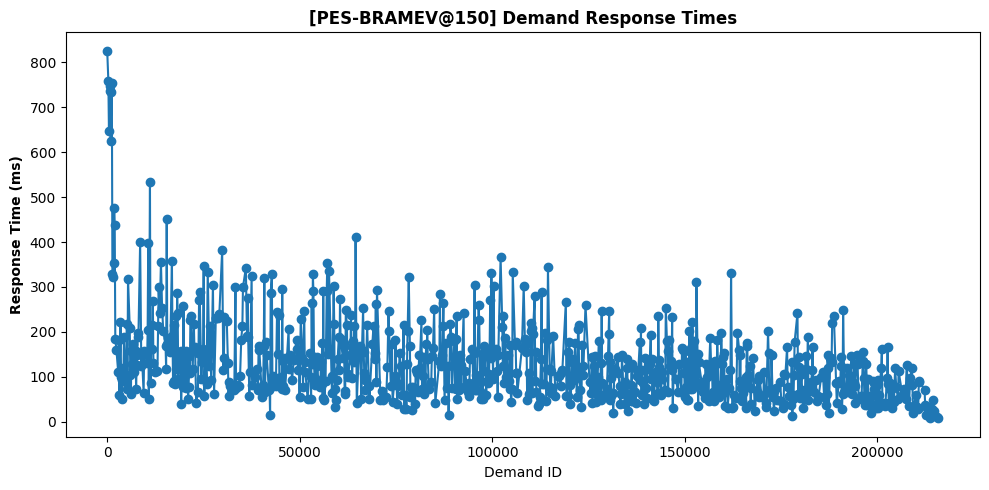

In [99]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

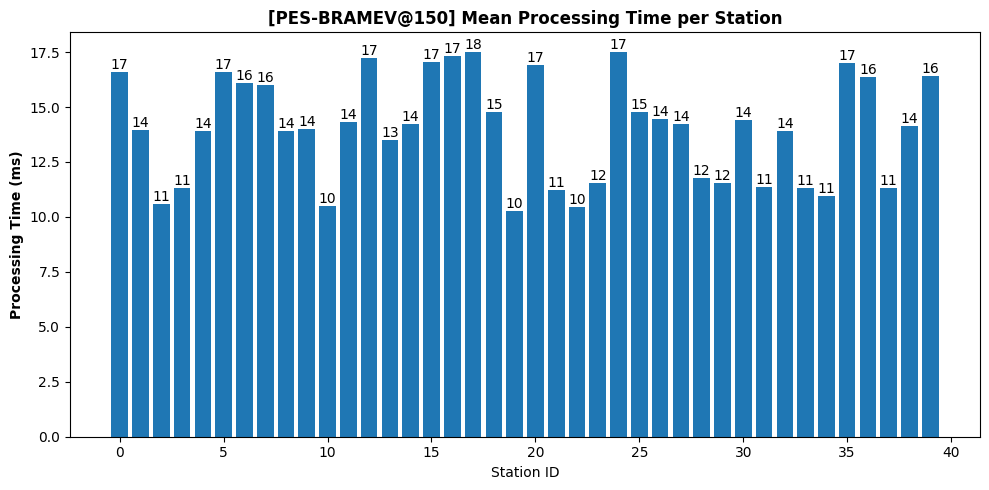

In [100]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

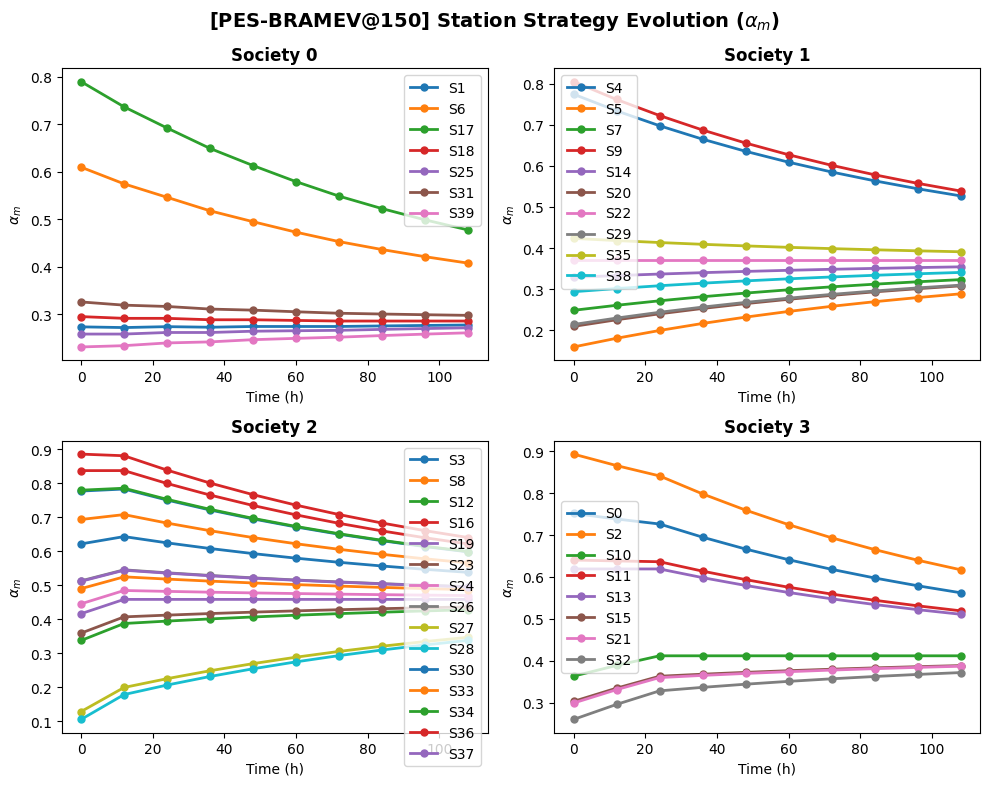

In [101]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [102]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.313194  0.065972  0.009722  0.000000  0.000000   
1            0           6  0.138194  0.044444  0.023611  0.000000  0.000000   
2            0          17  0.245833  0.078472  0.000000  0.000000  0.000000   
3            0          18  0.341667  0.160417  0.036111  0.000000  0.000000   
4            0          25  0.259028  0.121528  0.024306  0.000000  0.043750   
5            0          31  0.089583  0.076389  0.000000  0.000000       NaN   
6            0          39  0.236111  0.056944  0.018750  0.000000  0.000000   
7            1           4  0.370833  0.244444  0.068056  0.019444  0.000000   
8            1           5  0.183333  0.000000  0.000000  0.000000  0.000000   
9            1           7  0.434722  0.378472  0.091667  0.014583  0.022917   
10           1           9  0.145833  0.029167  0.000000  0.000000  0.000000   
11           1          14  0.260417  0.

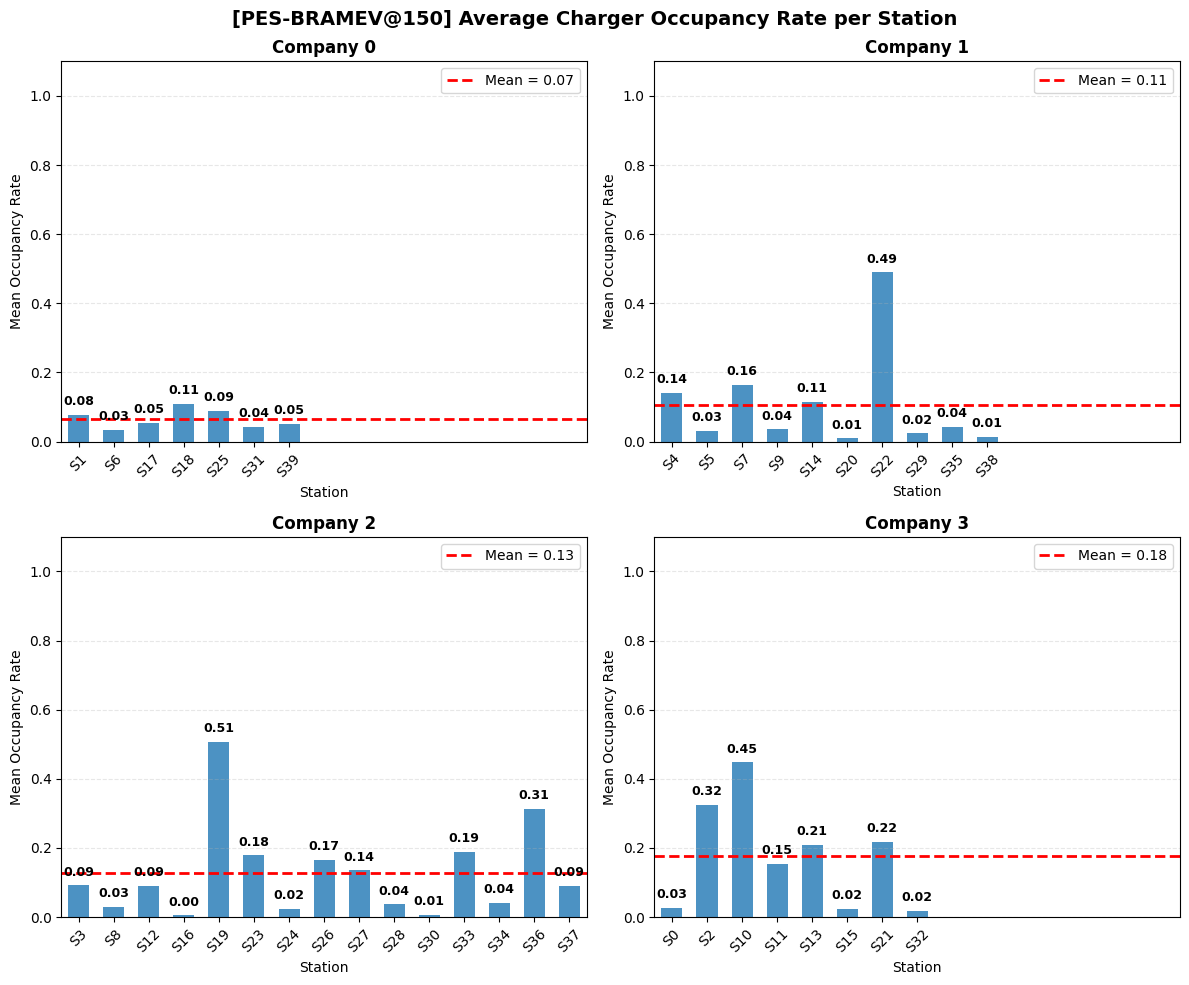

In [103]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

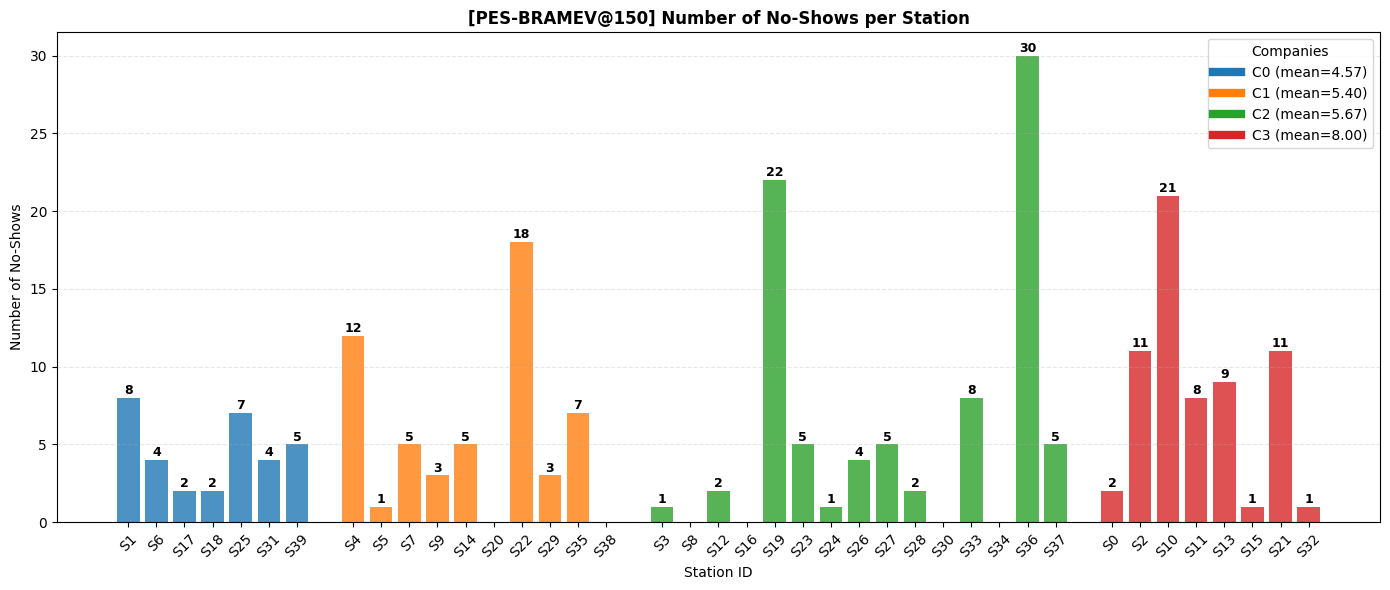

In [104]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [105]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,27,19,8,0,0,0.703704,0.296296,0.0,0.0
1,0,6,14,10,4,0,0,0.714286,0.285714,0.0,0.0
2,0,17,17,15,2,0,0,0.882353,0.117647,0.0,0.0
3,0,18,25,23,2,0,0,0.920000,0.080000,0.0,0.0
4,0,25,26,19,7,0,0,0.730769,0.269231,0.0,0.0
5,0,31,11,7,4,0,0,0.636364,0.363636,0.0,0.0
6,0,39,18,13,5,0,0,0.722222,0.277778,0.0,0.0
7,1,4,42,30,12,0,0,0.714286,0.285714,0.0,0.0
8,1,5,10,9,1,0,0,0.900000,0.100000,0.0,0.0
9,1,7,50,44,5,0,0,0.880000,0.100000,0.0,0.0


#### **COMPARISON**

##### *Params*

In [106]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

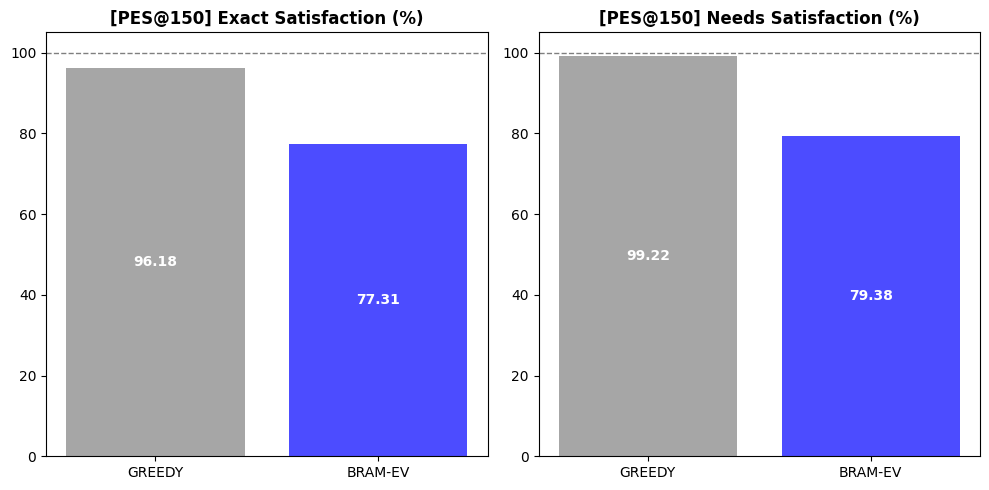

In [107]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

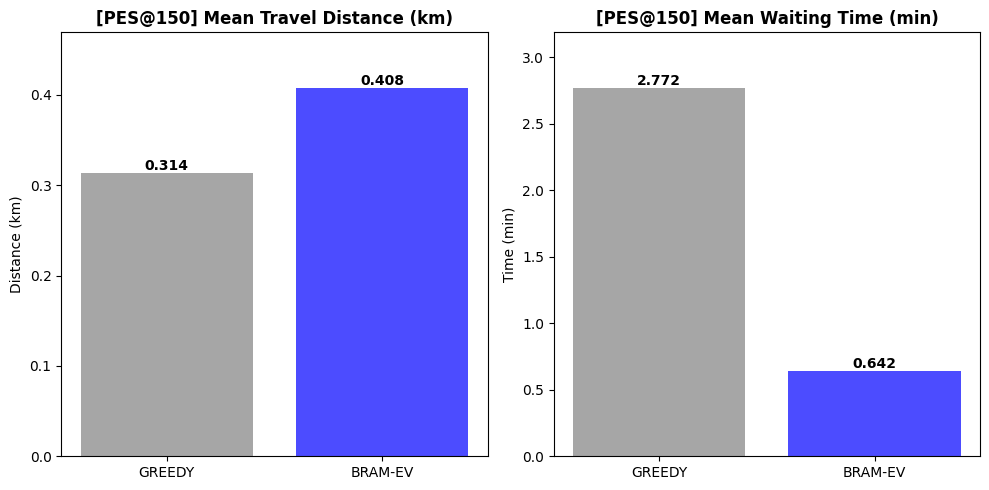

In [108]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

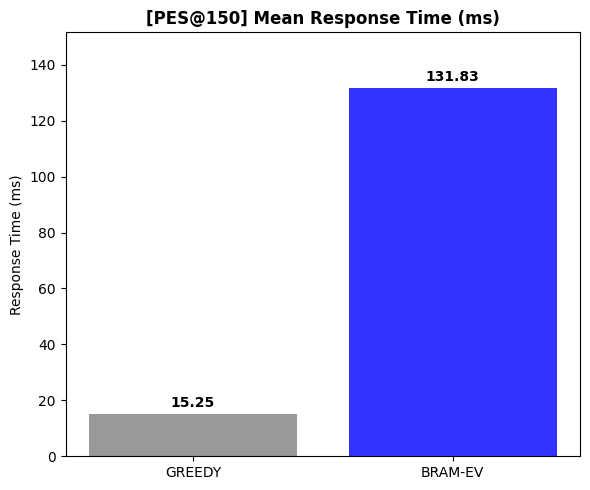

In [109]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@200cars**

#### **CONFIG**

In [110]:
nb_car = 200
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [111]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/200cars


##### *Initialisation*

In [112]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [113]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:21:35.904 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:21:36.163 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:21:36.390 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:21:36.736 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:21:36.985 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:21:37.173 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:21:37.458 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:21:37.635 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:21:37.851 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:21:38.087 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:21:38.470 | IN

##### *Metrics*

In [114]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 8.15 kWh
  Station 1: 40.38 kWh
  Station 2: 47.93 kWh
  Station 3: 6.18 kWh
  Station 4: 57.71 kWh
  Station 5: 1.93 kWh
  Station 6: 17.71 kWh
  Station 7: 83.97 kWh
  Station 8: 5.42 kWh
  Station 9: 11.62 kWh
  Station 10: 10.58 kWh
  Station 11: 10.32 kWh
  Station 12: 0.00 kWh
  Station 13: 20.77 kWh
  Station 14: 27.79 kWh
  Station 15: 6.59 kWh
  Station 16: 5.95 kWh
  Station 17: 27.55 kWh
  Station 18: 4.22 kWh
  Station 19: 55.83 kWh
  Station 20: 5.01 kWh
  Station 21: 51.96 kWh
  Station 22: 14.93 kWh
  Station 23: 6.84 kWh
  Station 24: 56.22 kWh
  Station 25: 2.93 kWh
  Station 26: 20.89 kWh
  Station 27: 7.81 kWh
  Station 28: 68.07 kWh
  Station 29: 9.82 kWh
  Station 30: 246.55 kWh
  Station 31: 74.29 kWh
  Station 32: 289.85 kWh
  Station 33: 24.39 kWh
  Station 34: 331.38 kWh
  Station 35: 97.21 kWh
  Station 36: 306.50 kWh
  Station 37: 12.67 kWh
  Station 38: 10.86 kWh
  Station 39: 63.02 

In [115]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

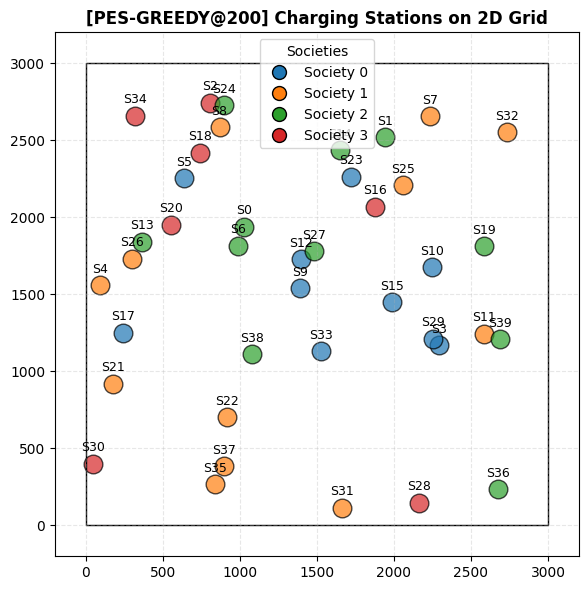

In [116]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

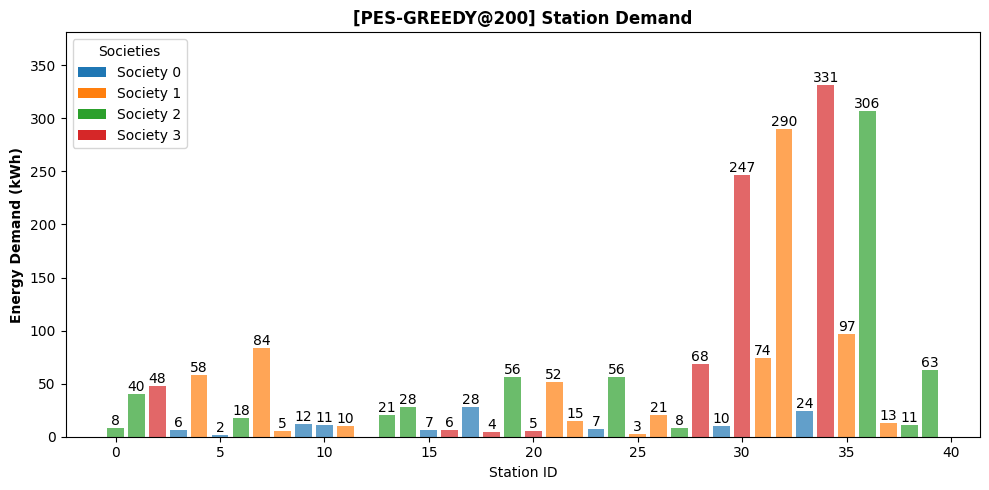

In [117]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

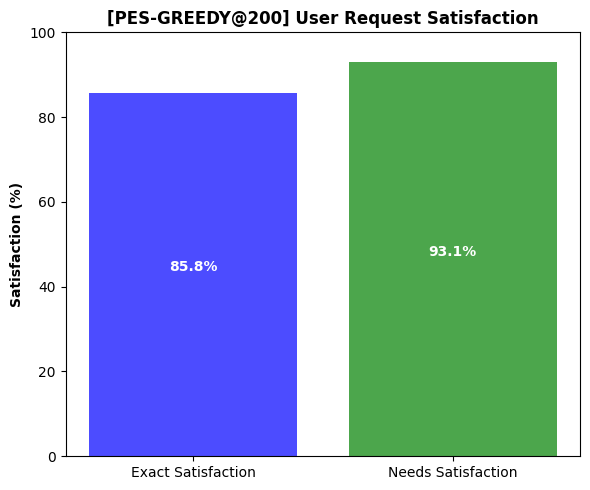

In [118]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

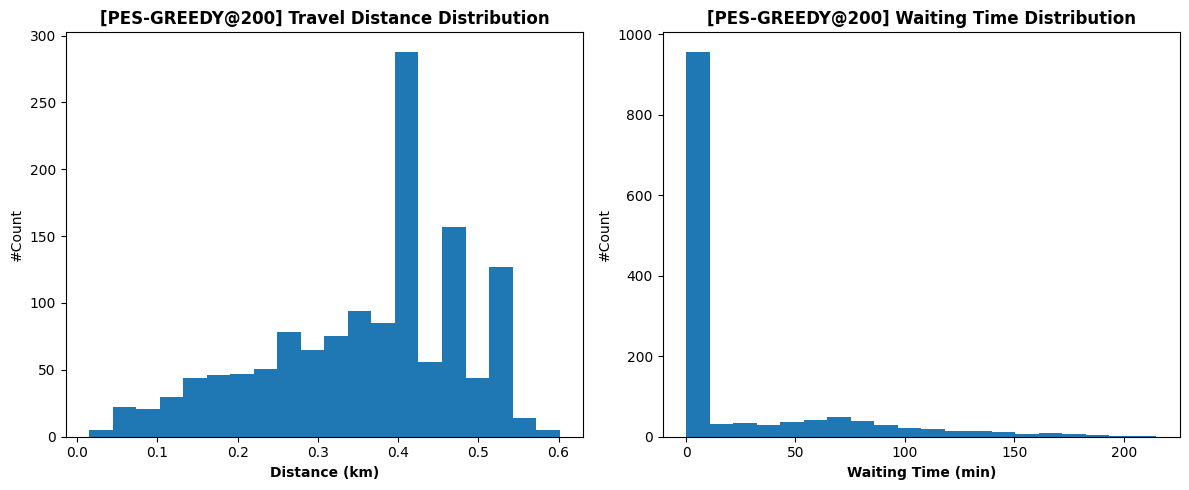

In [119]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

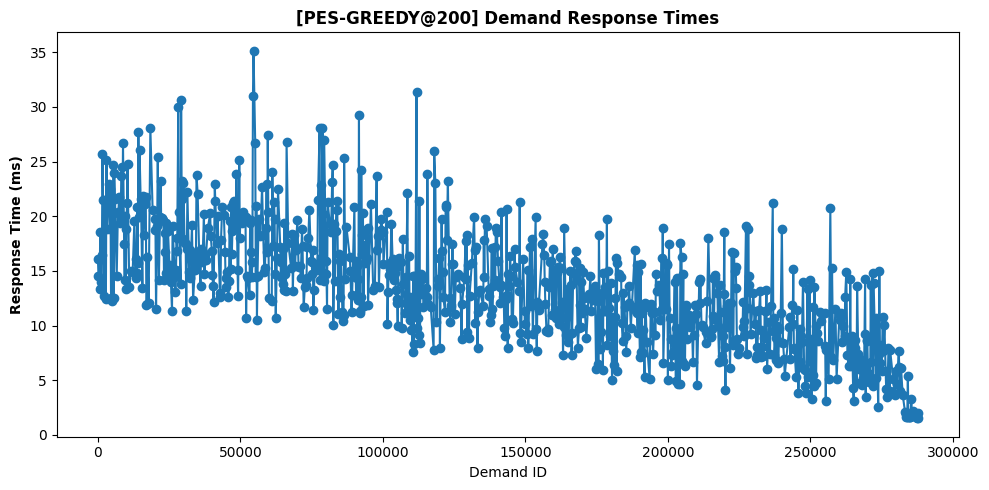

In [120]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

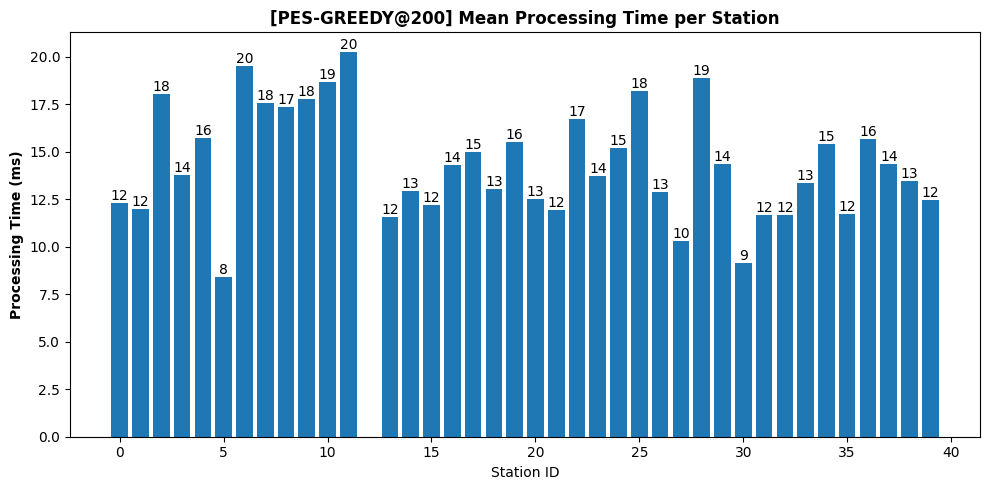

In [121]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [122]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [123]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [124]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:22:00.127 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:22:01.509 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:22:03.684 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:22:05.529 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:22:07.664 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:22:09.136 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:22:11.738 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:22:13.586 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:22:14.848 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:22:17.553 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:22:19.044 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [125]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 14.75 kWh
  Station 1: 32.62 kWh
  Station 2: 114.23 kWh
  Station 3: 12.13 kWh
  Station 4: 32.11 kWh
  Station 5: 54.68 kWh
  Station 6: 189.32 kWh
  Station 7: 39.10 kWh
  Station 8: 232.77 kWh
  Station 9: 34.16 kWh
  Station 10: 205.80 kWh
  Station 11: 2.00 kWh
  Station 12: 19.76 kWh
  Station 13: 97.51 kWh
  Station 14: 43.80 kWh
  Station 15: 23.72 kWh
  Station 16: 137.36 kWh
  Station 17: 20.66 kWh
  Station 18: 10.32 kWh
  Station 19: 74.04 kWh
  Station 20: 43.57 kWh
  Station 21: 58.29 kWh
  Station 22: 31.43 kWh
  Station 23: 42.84 kWh
  Station 24: 18.82 kWh
  Station 25: 121.00 kWh
  Station 26: 91.24 kWh
  Station 27: 20.47 kWh
  Station 28: 5.33 kWh
  Station 29: 8.82 kWh
  Station 30: 24.73 kWh
  Station 31: 8.72 kWh
  Station 32: 18.57 kWh
  Station 33: 8.44 kWh
  Station 34: 14.04 kWh
  Station 35: 40.80 kWh
  Station 36: 54.43 kWh
  Station 37: 117.51 kWh
  Station 38: 14.90 kWh
  Station

In [126]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

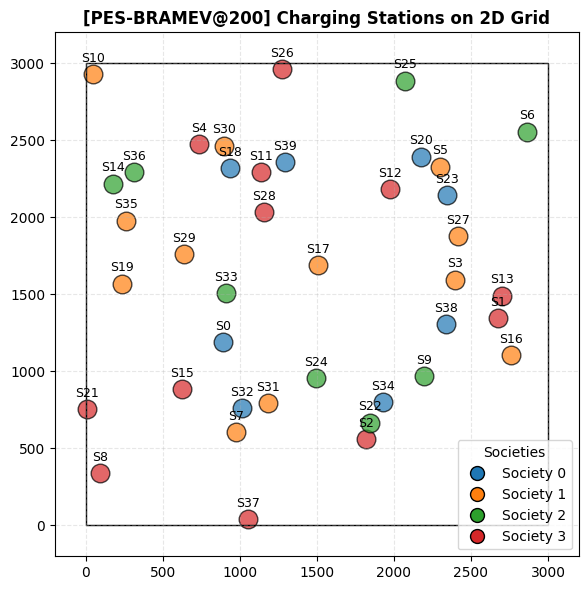

In [127]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

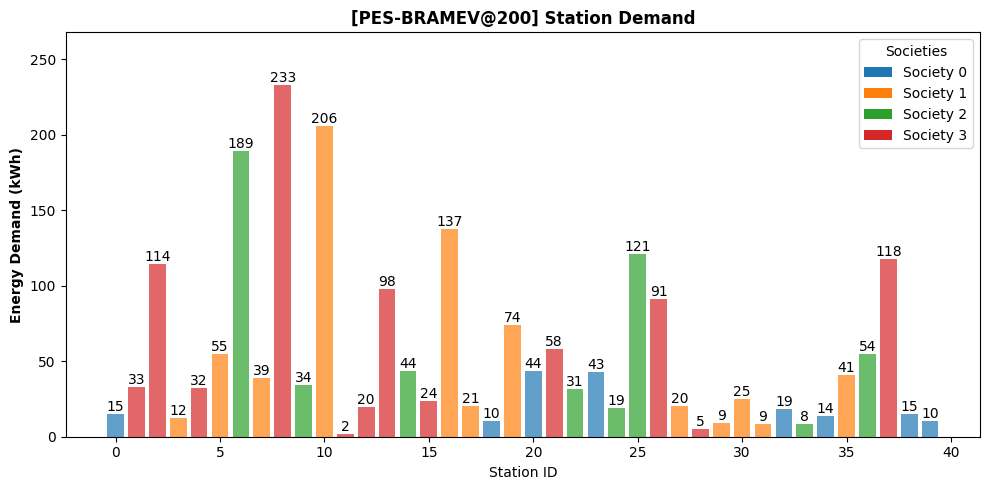

In [128]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

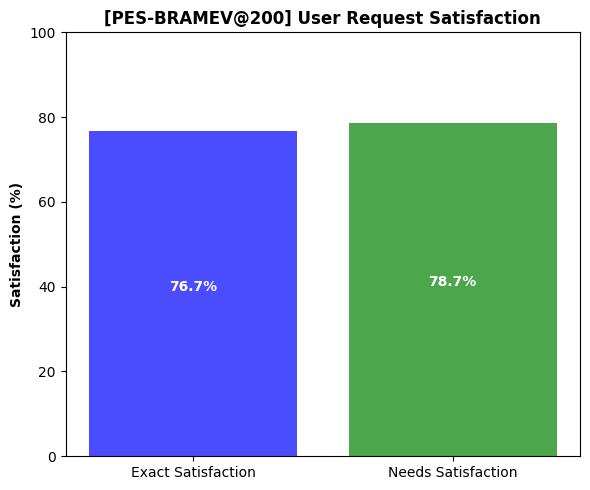

In [129]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

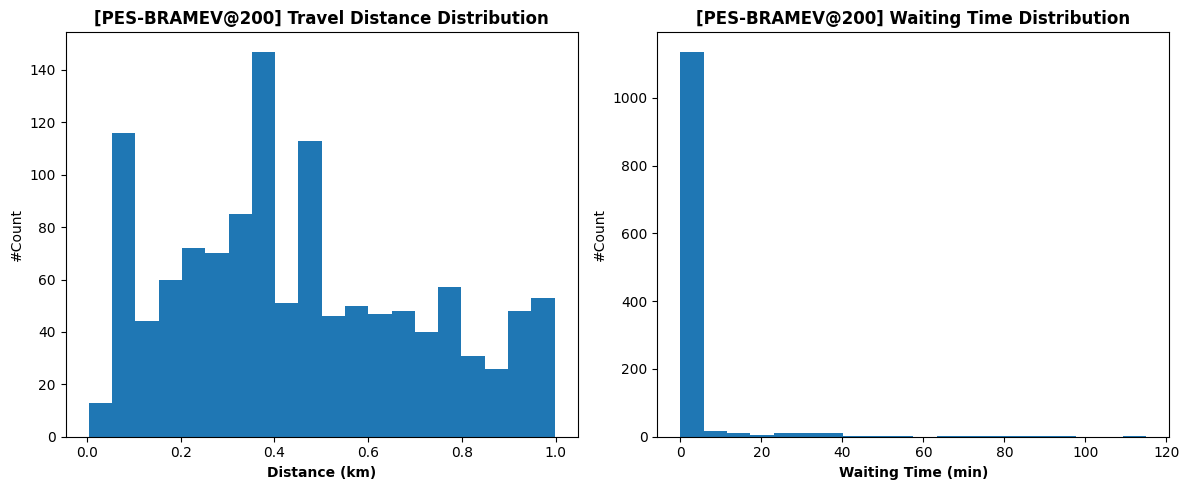

In [130]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

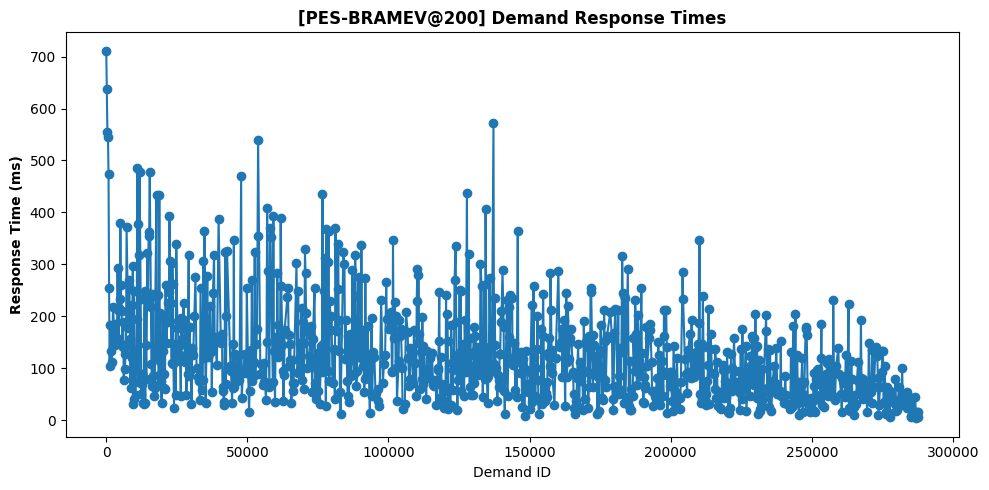

In [131]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

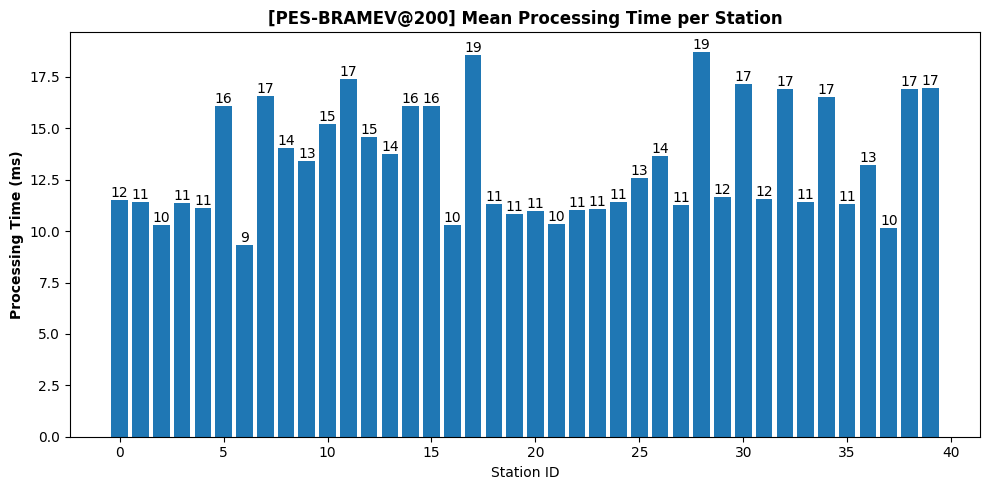

In [132]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

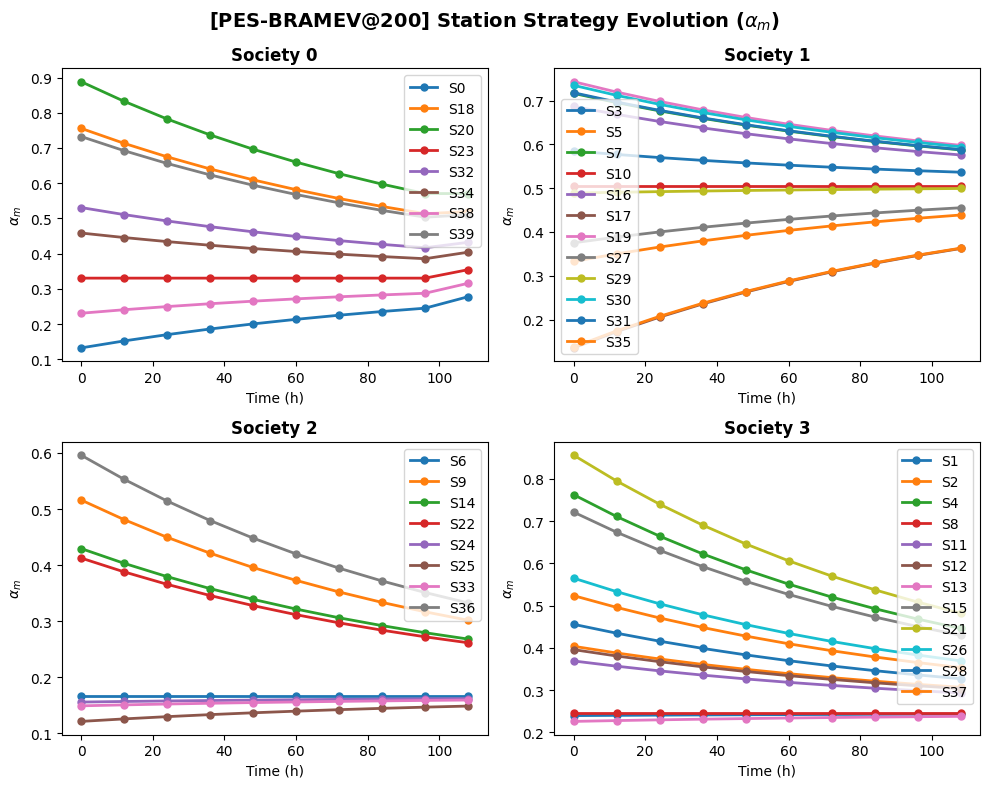

In [133]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [134]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           0  0.157639  0.025694  0.000000  0.000000       NaN   
1            0          18  0.145833  0.000000  0.000000  0.000000       NaN   
2            0          20  0.368750  0.123611  0.065972  0.059028       NaN   
3            0          23  0.344444  0.156944  0.031944  0.027778       NaN   
4            0          32  0.228472  0.034028  0.000000  0.000000  0.000000   
5            0          34  0.147917  0.025694  0.000000  0.000000  0.000000   
6            0          38  0.165972  0.070833  0.000000  0.000000  0.000000   
7            0          39  0.070139  0.018750  0.000000  0.000000  0.000000   
8            1           3  0.090278  0.050000  0.000000  0.000000       NaN   
9            1           5  0.381250  0.298611  0.103472  0.015278  0.000000   
10           1           7  0.313889  0.177083  0.040278  0.021528  0.000000   
11           1          10  0.632639  0.

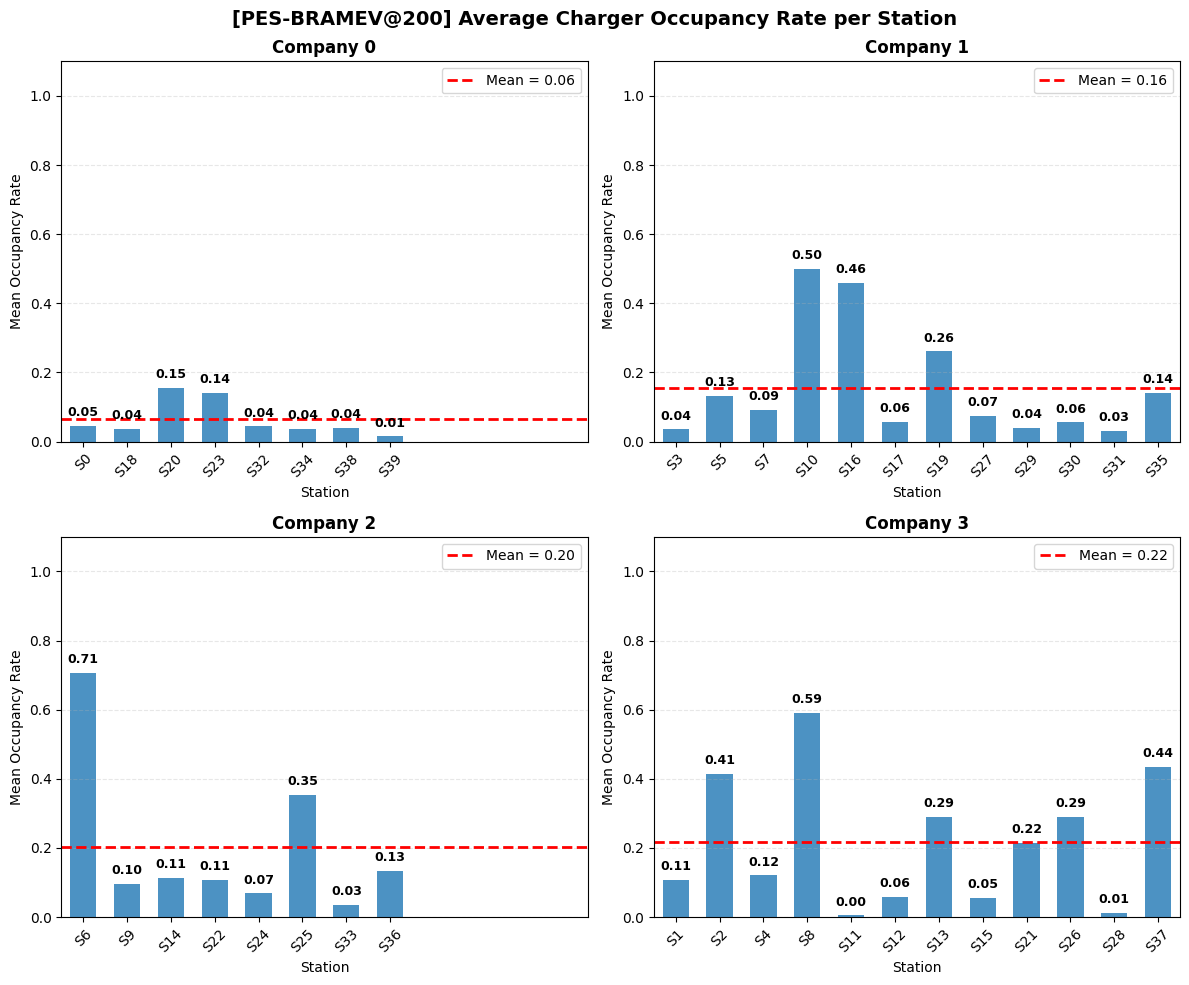

In [135]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

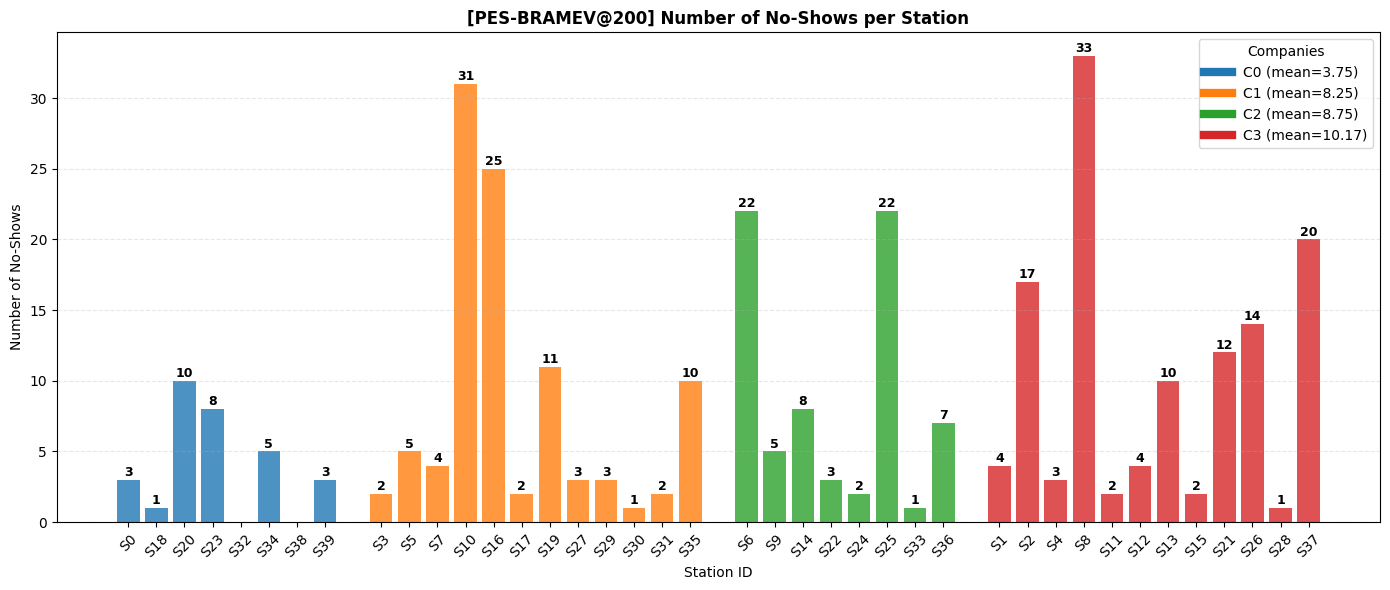

In [136]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [137]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,0,11,8,3,0,0,0.727273,0.272727,0.0,0.000000
1,0,18,6,5,1,0,0,0.833333,0.166667,0.0,0.000000
2,0,20,38,25,10,0,0,0.657895,0.263158,0.0,0.000000
3,0,23,32,24,8,0,0,0.750000,0.250000,0.0,0.000000
4,0,32,10,10,0,0,0,1.000000,0.000000,0.0,0.000000
5,0,34,12,7,5,0,0,0.583333,0.416667,0.0,0.000000
6,0,38,8,8,0,0,0,1.000000,0.000000,0.0,0.000000
7,0,39,8,5,3,0,0,0.625000,0.375000,0.0,0.000000
8,1,3,8,6,2,0,0,0.750000,0.250000,0.0,0.000000
9,1,5,38,33,5,0,0,0.868421,0.131579,0.0,0.000000


#### **COMPARISON**

##### *Params*

In [138]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

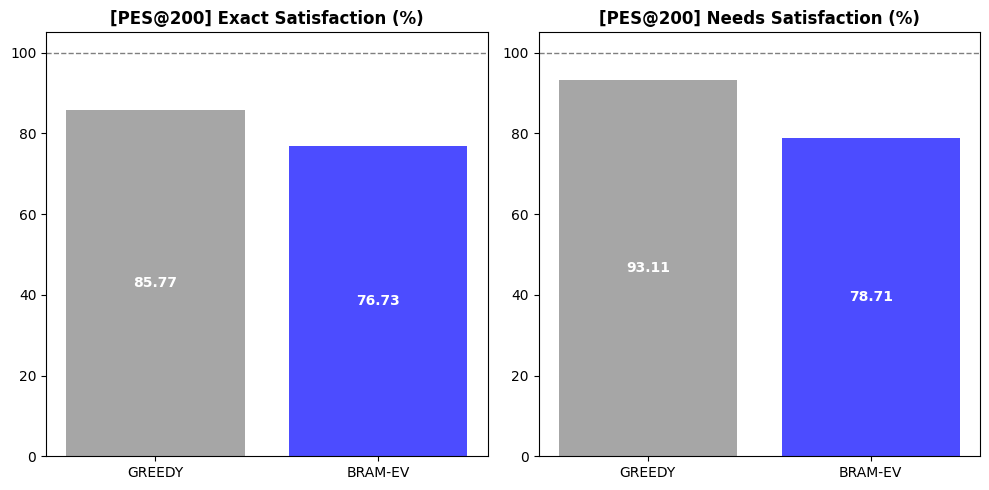

In [139]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

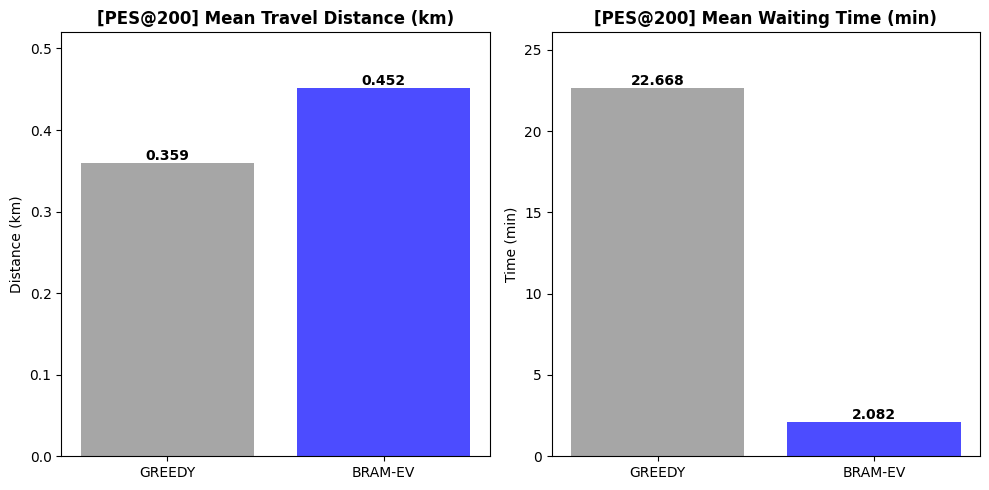

In [140]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

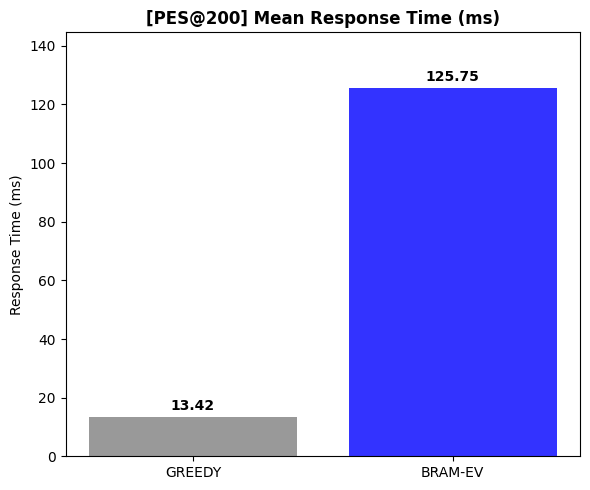

In [141]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

### **EVChargingManagement@250cars**

#### **CONFIG**

In [142]:
nb_car = 250
nb_car_list.append(nb_car)

sim_config = notebook_config(total_time=TOTAL_TIME, nb_car=nb_car, nb_society=NB_SOCIETY,
                nb_station=NB_STATION, base_car_behavior=BASE_CAR_BEHAVIOR,
                station_strategy_noise=STRATEGY_NOISE, log_iter=LOG_ITER)

#### **GREEDY APPROACH**

##### *Params*

In [143]:
approach_name = 'greedy'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)

print(f'Experiment outputs logs in folder: {approach_log_folder}')

Experiment outputs logs in folder: /Users/fatoumatawadiou/Documents/Academique/ING3/25-26/COURS/PFE/EVChargingManagement/outputs/pessimistic/greedy/250cars


##### *Initialisation*

In [144]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [145]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

greedy_simulation = sim_greedy.SimulationGreedy(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
greedy_simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:24:08.219 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 12/1440
2026-06-13 20:24:08.581 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 24/1440
2026-06-13 20:24:08.869 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 36/1440
2026-06-13 20:24:09.115 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 48/1440
2026-06-13 20:24:09.468 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 60/1440
2026-06-13 20:24:09.793 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 72/1440
2026-06-13 20:24:10.134 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 84/1440
2026-06-13 20:24:10.487 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 96/1440
2026-06-13 20:24:10.761 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 108/1440
2026-06-13 20:24:10.945 | INFO     | src.experiments.simulation_greedy:step:93 - INSTANT 120/1440
2026-06-13 20:24:11.276 | IN

##### *Metrics*

In [146]:
greedy_simulation.metrics.print_report()
greedy_simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 52.67 kWh
  Station 1: 6.47 kWh
  Station 2: 71.50 kWh
  Station 3: 13.11 kWh
  Station 4: 13.29 kWh
  Station 5: 20.35 kWh
  Station 6: 11.99 kWh
  Station 7: 9.31 kWh
  Station 8: 23.81 kWh
  Station 9: 253.26 kWh
  Station 10: 9.26 kWh
  Station 11: 60.88 kWh
  Station 12: 14.76 kWh
  Station 13: 12.74 kWh
  Station 14: 31.93 kWh
  Station 15: 7.04 kWh
  Station 16: 3.47 kWh
  Station 17: 78.76 kWh
  Station 18: 4.88 kWh
  Station 19: 13.19 kWh
  Station 20: 88.54 kWh
  Station 21: 380.84 kWh
  Station 22: 82.94 kWh
  Station 23: 318.63 kWh
  Station 24: 54.83 kWh
  Station 25: 6.88 kWh
  Station 26: 9.67 kWh
  Station 27: 23.43 kWh
  Station 28: 12.91 kWh
  Station 29: 87.16 kWh
  Station 30: 6.92 kWh
  Station 31: 3.88 kWh
  Station 32: 15.56 kWh
  Station 33: 81.53 kWh
  Station 34: 30.43 kWh
  Station 35: 98.17 kWh
  Station 36: 90.17 kWh
  Station 37: 345.33 kWh
  Station 38: 118.66 kWh
  Station 39: 12

In [147]:
greedy_results = greedy_simulation.metrics.report()

exact_satif_greedy = greedy_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_greedy = greedy_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_greedy = greedy_results['mean_travel_distance_km']                                  # en km
mean_waiting_greedy = greedy_results['mean_waiting_time_h']*60                                  # en min
mean_response_greedy = greedy_results['mean_response_time_ms']                                  # en ms

exact_satif_greedy_list.append(exact_satif_greedy)
needs_satif_greedy_list.append(needs_satif_greedy)
mean_travel_greedy_list.append(mean_travel_greedy)
mean_waiting_greedy_list.append(mean_waiting_greedy)
mean_response_greedy_list.append(mean_response_greedy)

##### *Display*

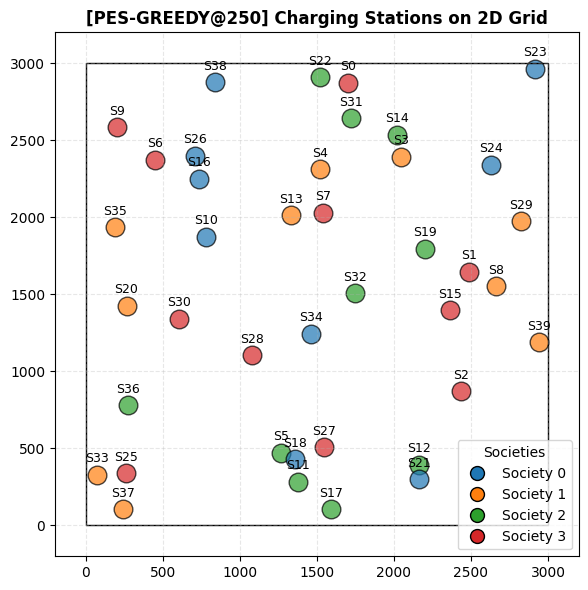

In [148]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

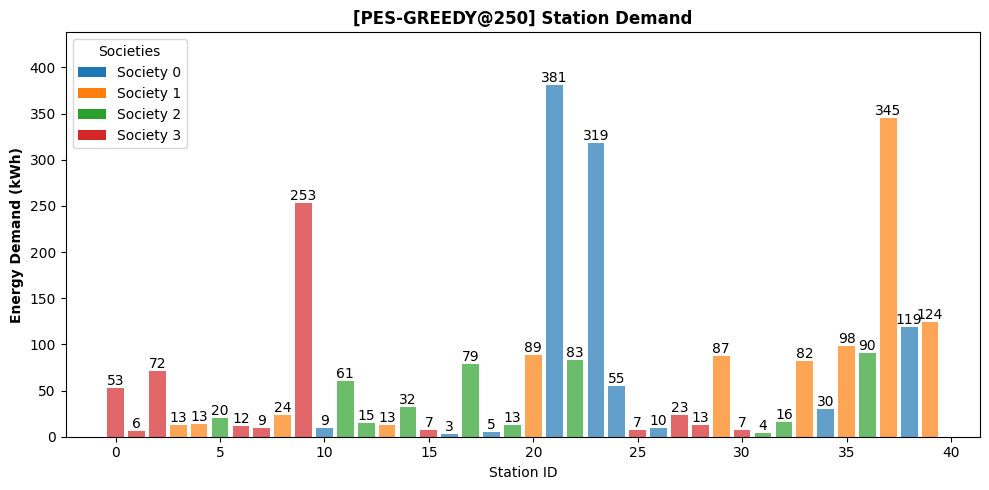

In [149]:
plot_station_demand(greedy_simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

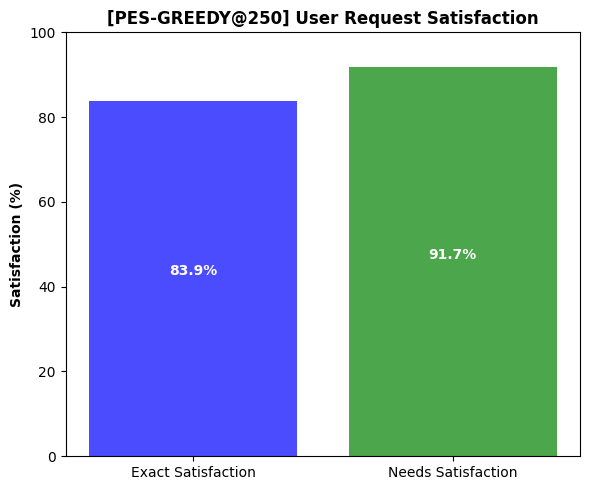

In [150]:
plot_user_satisfaction(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

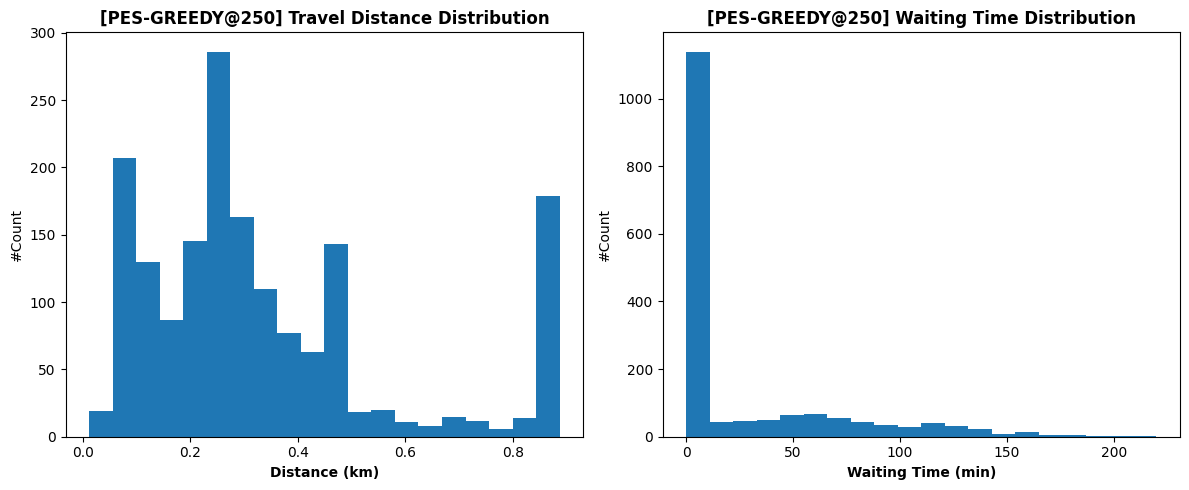

In [151]:
plot_travel_waiting(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

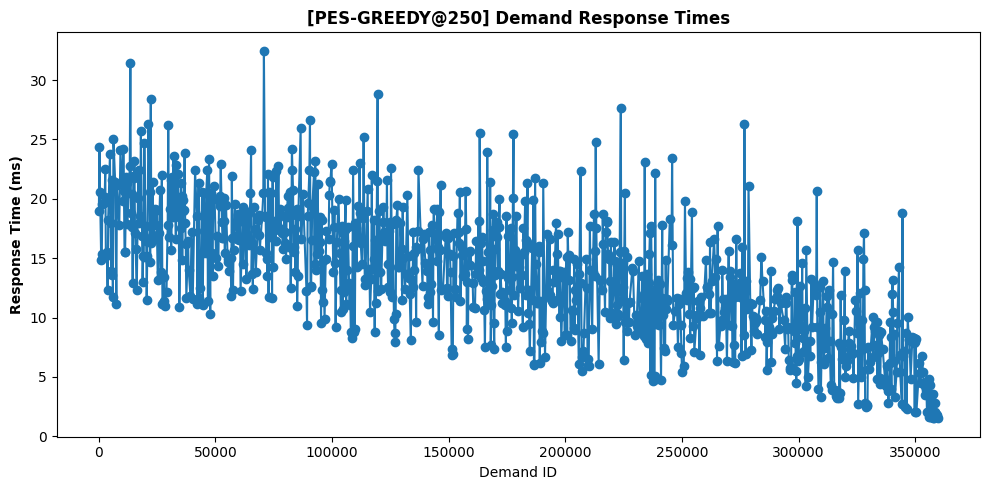

In [152]:
plot_response_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

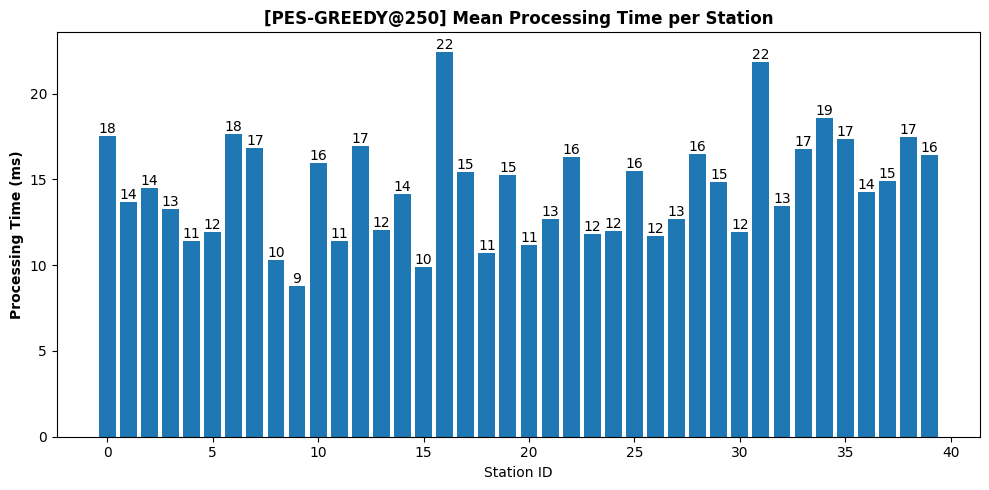

In [153]:
plot_processing_times(greedy_simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

#### **BRAM-EV**

##### *Params*

In [154]:
approach_name = 'bramev'
approach_folder = f'{approach_name}/{nb_car}cars'
approach_log_folder = f'{OUTPUT_FOLDER_PATH}/{approach_folder}'
os.makedirs(approach_log_folder, exist_ok=True)


##### *Initialisation*

In [155]:
# ---- OPEN LOG FILES

summary_file = open(f'{approach_log_folder}/agents_init.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

summary_file.write('\n--------- AGENTS DEFINITION')

summary_file.write("=== Initialisation des agents ===")
cars, stations, societies = define_agents(sim_config)
summary_file.write(f'\n--- {sim_config.NB_CARS} CAR ---')
for car in cars:
    summary_file.write('\n')
    car.display_parameters(file=summary_file)

summary_file.write(f'\n--- {sim_config.NB_SOCIETIES} SOCIETIES ---')
count_society = 1
for society in societies:
    summary_file.write(f'\n --------------- SOCIETY {count_society}/{sim_config.NB_SOCIETIES} ---------------')
    count_society += 1
    society.display_parameters(file=summary_file)
    summary_file.write('\n -------- ATTACHED STATIONS:')
    for station in society.stations:
        summary_file.write('\n')
        station.display_parameters(file=summary_file)

summary_file.write(f"\n=== Simulation started with {len(cars)} cars and {len(stations)} stations. ===")


58

##### *Run*

In [156]:
# ----- LANCEMENT SIMULATION

simulation_file = open(f'{approach_log_folder}/experiment_log.txt', 'w', 
                    encoding='utf-8') # init file: init state of agents

simulation_file.write(f"=== Lancement simulation : {sim_config.NB_CARS} voitures, "
        f"{sim_config.NB_STATIONS} stations, {sim_config.TOTAL_TIME} slots ===\n")

simulation = sim_module.Simulation(
    cars=cars,
    stations=stations,
    societies=societies,
    t_max=sim_config.TOTAL_TIME,
    config=sim_config
)
simulation.run(file=simulation_file, print_metrics=False)

2026-06-13 20:24:41.426 | INFO     | src.experiments.simulation:step:53 - INSTANT 12/1440
2026-06-13 20:24:49.455 | INFO     | src.experiments.simulation:step:53 - INSTANT 24/1440
2026-06-13 20:24:53.820 | INFO     | src.experiments.simulation:step:53 - INSTANT 36/1440
2026-06-13 20:24:55.762 | INFO     | src.experiments.simulation:step:53 - INSTANT 48/1440
2026-06-13 20:24:57.878 | INFO     | src.experiments.simulation:step:53 - INSTANT 60/1440
2026-06-13 20:24:59.128 | INFO     | src.experiments.simulation:step:53 - INSTANT 72/1440
2026-06-13 20:25:00.486 | INFO     | src.experiments.simulation:step:53 - INSTANT 84/1440
2026-06-13 20:25:02.840 | INFO     | src.experiments.simulation:step:53 - INSTANT 96/1440
2026-06-13 20:25:04.703 | INFO     | src.experiments.simulation:step:53 - INSTANT 108/1440
2026-06-13 20:25:06.204 | INFO     | src.experiments.simulation:step:53 - INSTANT 120/1440
2026-06-13 20:25:08.850 | INFO     | src.experiments.simulation:step:53 - INSTANT 132/1440
2026-06

##### *Metrics*

In [157]:
simulation.metrics.print_report()
simulation.breakdowns.print_report()


========== MÉTRIQUES ==========

--- Station Demand (kWh) ---
  Station 0: 119.67 kWh
  Station 1: 16.43 kWh
  Station 2: 111.75 kWh
  Station 3: 199.38 kWh
  Station 4: 79.08 kWh
  Station 5: 129.72 kWh
  Station 6: 7.62 kWh
  Station 7: 34.01 kWh
  Station 8: 15.80 kWh
  Station 9: 10.94 kWh
  Station 10: 152.82 kWh
  Station 11: 89.00 kWh
  Station 12: 108.39 kWh
  Station 13: 34.12 kWh
  Station 14: 112.28 kWh
  Station 15: 11.73 kWh
  Station 16: 12.22 kWh
  Station 17: 48.08 kWh
  Station 18: 233.40 kWh
  Station 19: 9.59 kWh
  Station 20: 59.26 kWh
  Station 21: 26.12 kWh
  Station 22: 23.62 kWh
  Station 23: 118.07 kWh
  Station 24: 30.74 kWh
  Station 25: 41.04 kWh
  Station 26: 5.30 kWh
  Station 27: 122.64 kWh
  Station 28: 21.47 kWh
  Station 29: 15.37 kWh
  Station 30: 213.04 kWh
  Station 31: 26.36 kWh
  Station 32: 78.49 kWh
  Station 33: 6.91 kWh
  Station 34: 34.66 kWh
  Station 35: 13.50 kWh
  Station 36: 1.52 kWh
  Station 37: 44.83 kWh
  Station 38: 213.22 kWh
  St

In [158]:
bramev_results = simulation.metrics.report()

exact_satif_bramev = bramev_results['user_request_satisfaction']['exact_satisfaction'] * 100    # en %
needs_satif_bramev = bramev_results['user_request_satisfaction']['needs_satisfaction'] * 100    # en %
mean_travel_bramev = bramev_results['mean_travel_distance_km']                                  # en km
mean_waiting_bramev = bramev_results['mean_waiting_time_h'] * 60                                # en min
mean_response_bramev = bramev_results['mean_response_time_ms']                                  # en ms

exact_satif_bramev_list.append(exact_satif_bramev)
needs_satif_bramev_list.append(needs_satif_bramev)
mean_travel_bramev_list.append(mean_travel_bramev)
mean_waiting_bramev_list.append(mean_waiting_bramev)
mean_response_bramev_list.append(mean_response_bramev)

##### *Display*

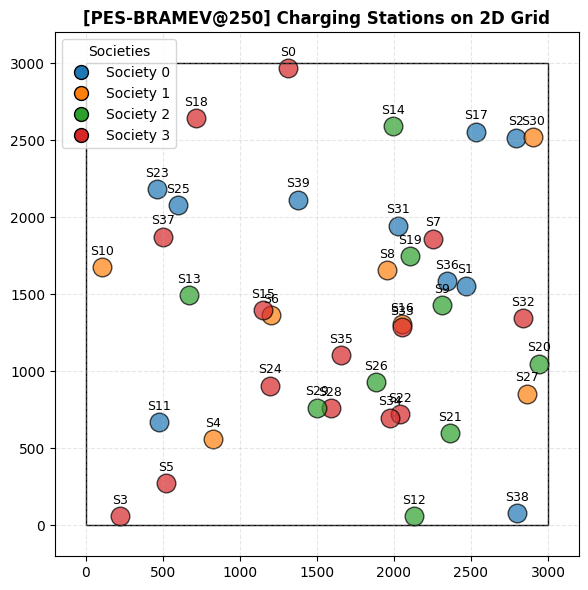

In [159]:
plot_stations_2d(stations, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(6, 6), padding=200)

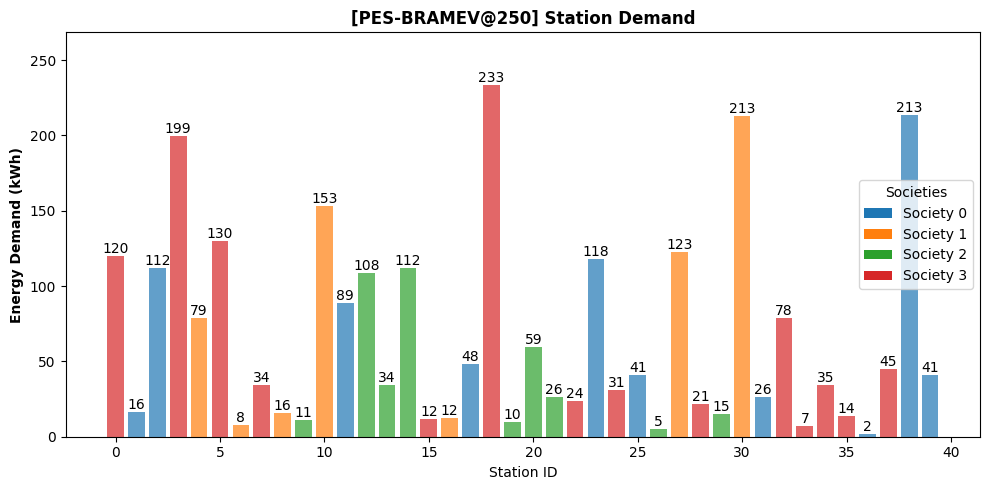

In [160]:
plot_station_demand(simulation.metrics, societies=societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car, figsize=(10, 5))

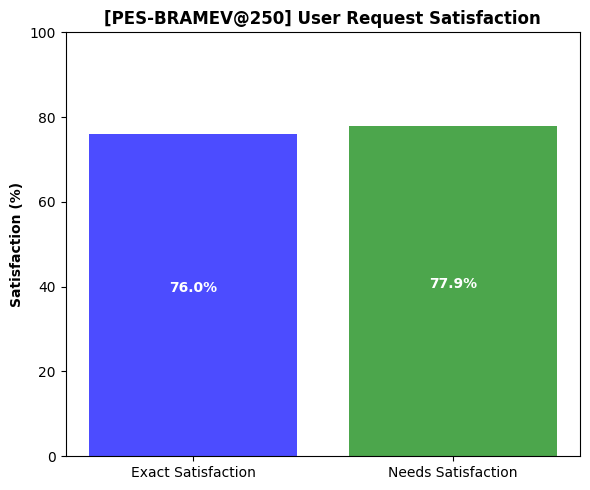

In [161]:
plot_user_satisfaction(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

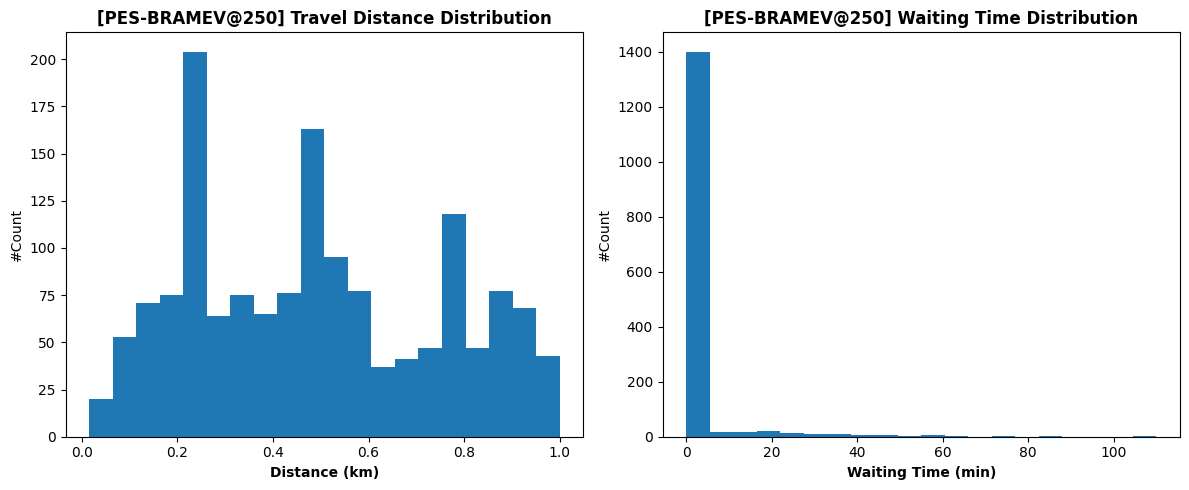

In [162]:
plot_travel_waiting(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

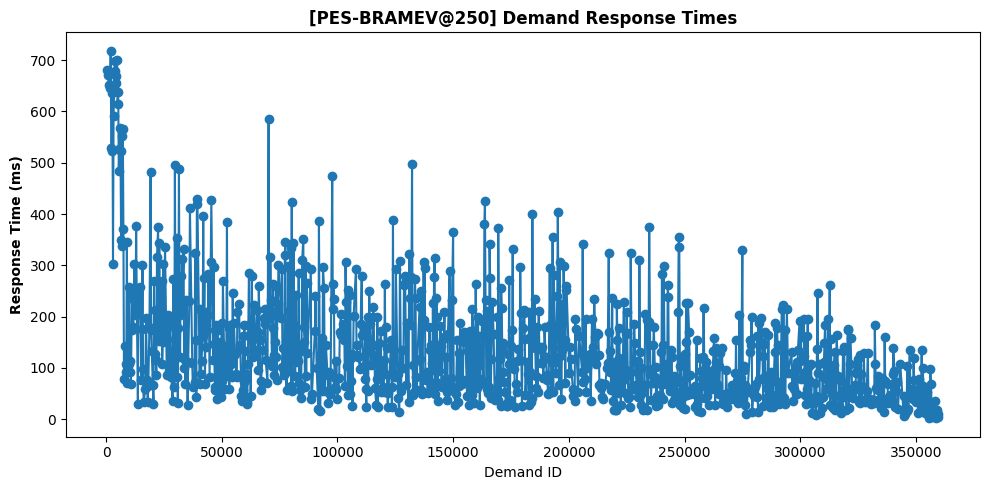

In [163]:
plot_response_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

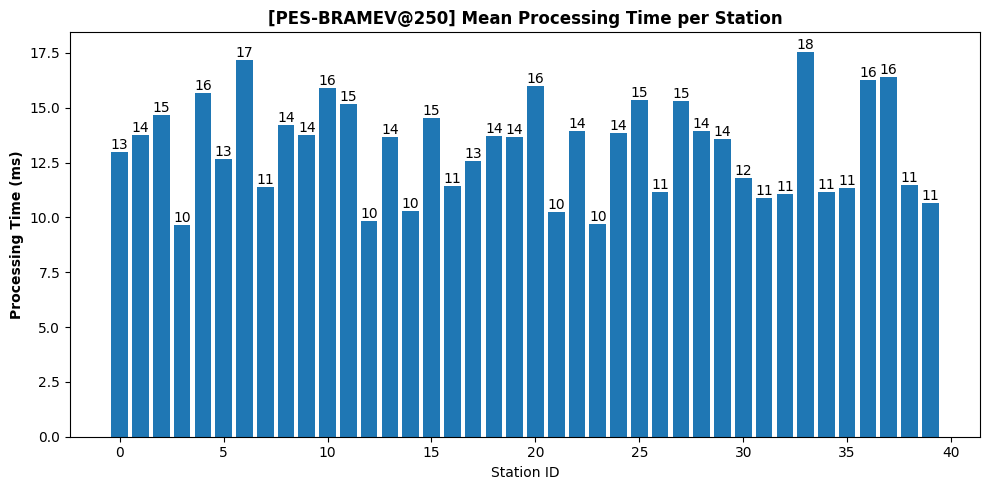

In [164]:
plot_processing_times(simulation.metrics, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

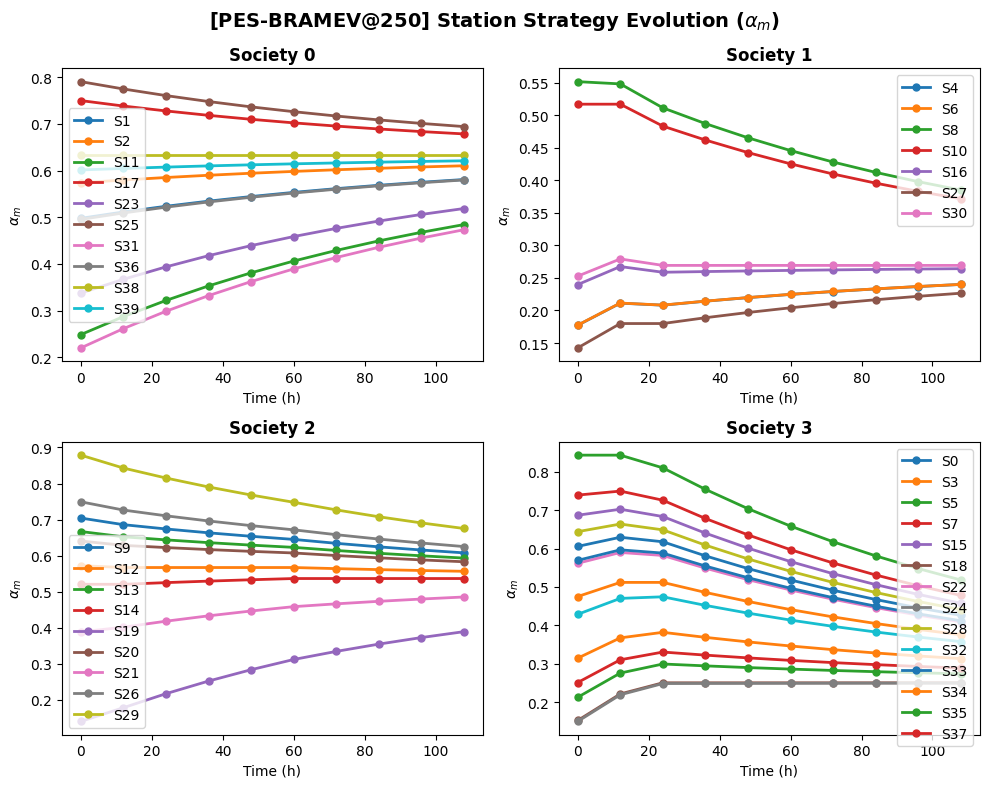

In [165]:
plot_station_strategies(societies, sim_config, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

##### *Other metrics*

CHARGER OCCUPANCY RATE

In [166]:
df_occ = create_station_occupancy_dataframe(societies)

print(df_occ)

    id_society  id_station   borne_1   borne_2   borne_3   borne_4   borne_5  \
0            0           1  0.189583  0.040972  0.000000  0.000000  0.000000   
1            0           2  0.447222  0.478472  0.237500  0.128472  0.118750   
2            0          11  0.432639  0.256250  0.131944  0.083333  0.041667   
3            0          17  0.284028  0.240972  0.061111  0.027778  0.040278   
4            0          23  0.475000  0.454167  0.268750  0.466667       NaN   
5            0          25  0.365972  0.138889  0.000000  0.000000  0.028472   
6            0          31  0.226389  0.068056  0.052083  0.000000       NaN   
7            0          36  0.018056  0.000000  0.000000  0.000000  0.000000   
8            0          38  0.645833  0.715278  0.627778  0.529167  0.552083   
9            0          39  0.330556  0.156944  0.020139  0.038194       NaN   
10           1           4  0.555556  0.307639  0.090278  0.029861  0.000000   
11           1           6  0.093750  0.

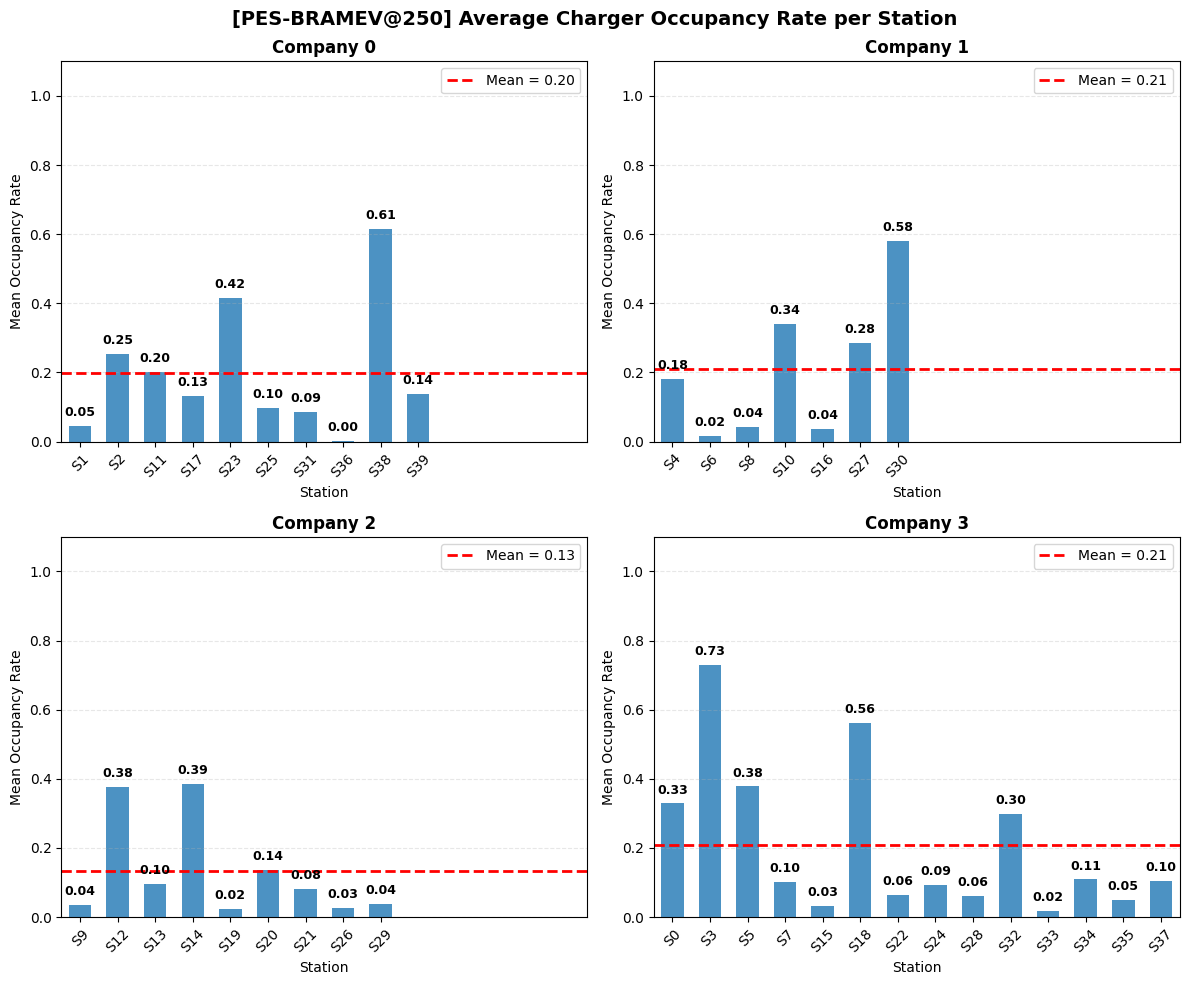

In [167]:
plot_society_station_occupancy(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

NUMBER OF NO SHOW

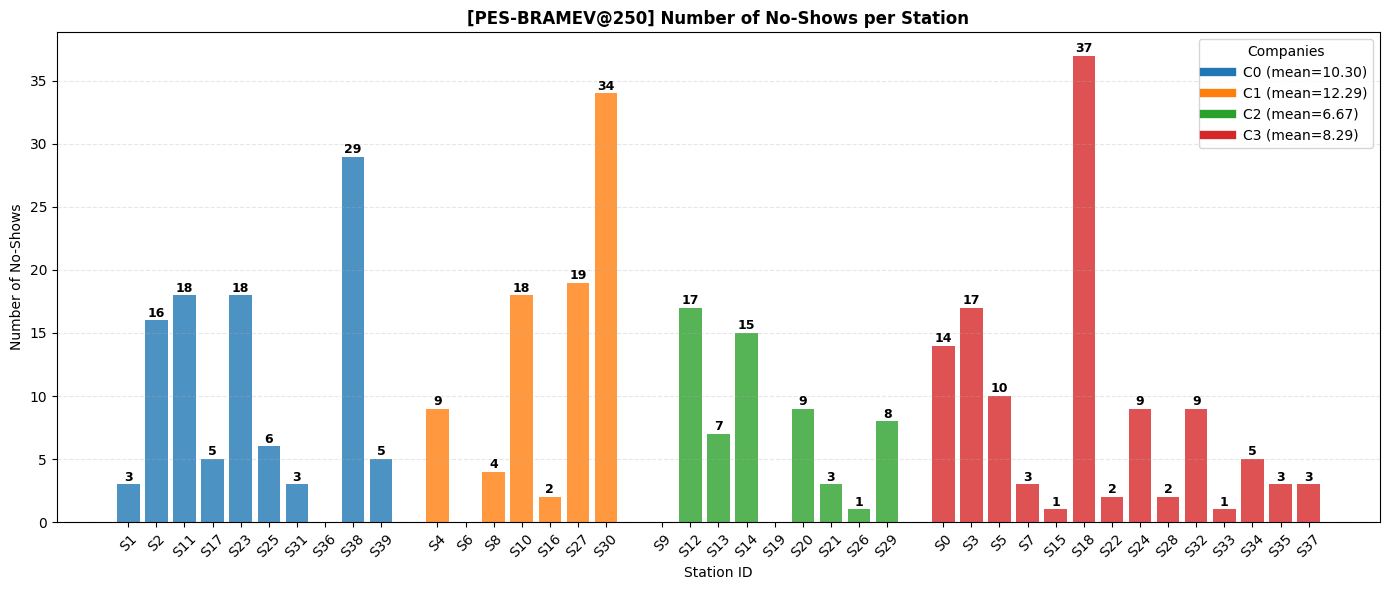

In [168]:
plot_station_no_show(societies, scenario_name=SCENARIO,
                 approach_name=approach_name, nb_car=nb_car)

In [169]:
df_nb_res = create_station_reservation_dataframe(societies)
df_nb_res

,id_society,id_station,nb_reservation,nb_pres,nb_abs,nb_early,nb_late,p_pres,p_abs,p_early,p_late
0,0,1,13,9,3,0,0,0.692308,0.230769,0.0,0.0
1,0,2,82,62,16,0,0,0.756098,0.195122,0.0,0.0
2,0,11,69,49,18,0,0,0.710145,0.260870,0.0,0.0
3,0,17,32,27,5,0,0,0.843750,0.156250,0.0,0.0
4,0,23,88,69,18,0,0,0.784091,0.204545,0.0,0.0
5,0,25,28,22,6,0,0,0.785714,0.214286,0.0,0.0
6,0,31,19,16,3,0,0,0.842105,0.157895,0.0,0.0
7,0,36,1,1,0,0,0,1.000000,0.000000,0.0,0.0
8,0,38,156,123,29,0,0,0.788462,0.185897,0.0,0.0
9,0,39,28,23,5,0,0,0.821429,0.178571,0.0,0.0


#### **COMPARISON**

##### *Params*

In [170]:
labels = ['GREEDY', 'BRAM-EV']
colors = ['grey', 'blue']

##### *Demand satisfaction*

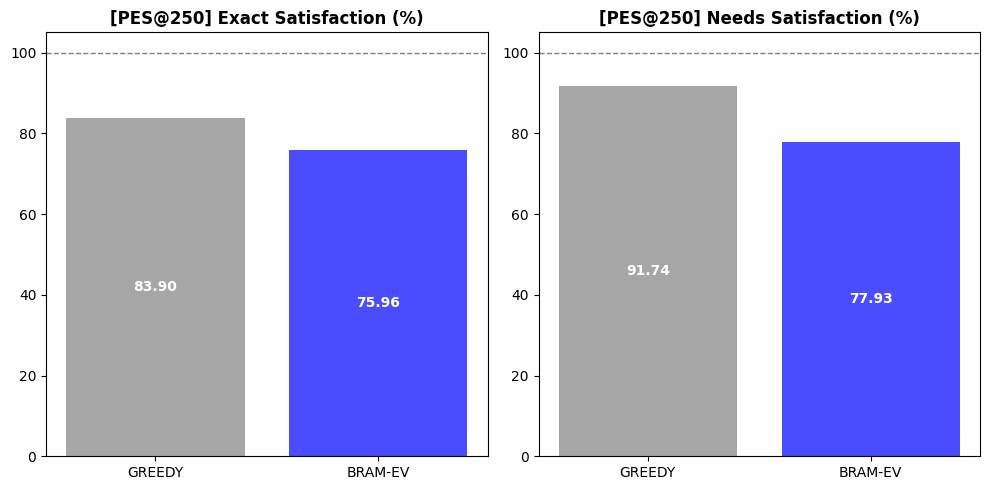

In [171]:
exact_values = [exact_satif_greedy, exact_satif_bramev]
needs_values = [needs_satif_greedy, needs_satif_bramev]

plot_exact_needs_comparison(exact_values, needs_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Travel & Waiting*

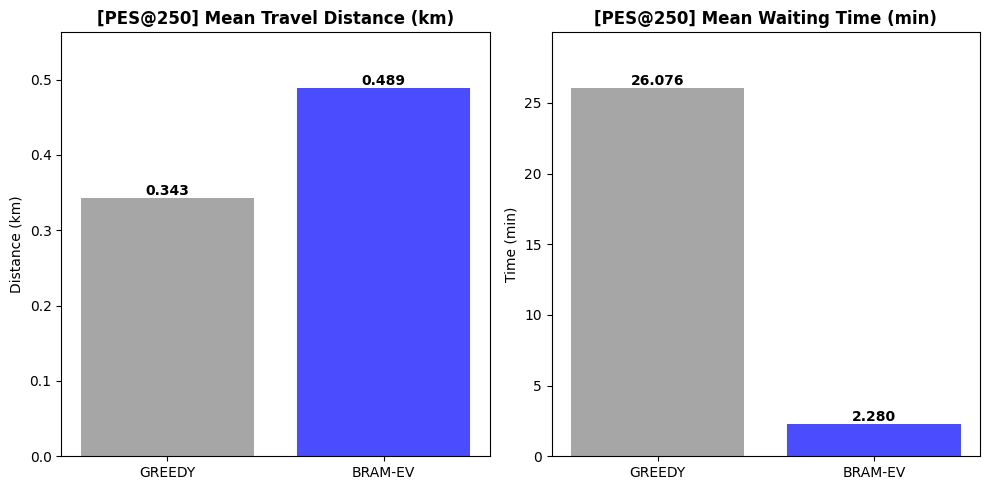

In [172]:
travel_values = [mean_travel_greedy, mean_travel_bramev]
waiting_values = [mean_waiting_greedy, mean_waiting_bramev]

plot_travel_waiting_comparison(travel_values, waiting_values, labels, 
                            colors, scenario_name=SCENARIO, nb_car=nb_car)

##### *Scalability*

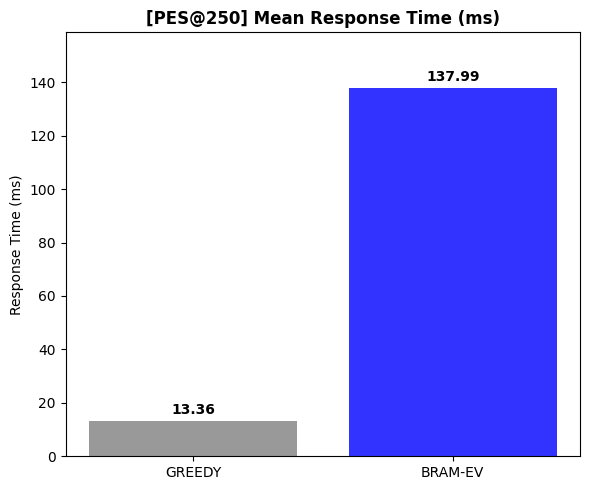

In [173]:
mean_response = [mean_response_greedy, mean_response_bramev]
plot_mean_response_time_comparison(labels, colors, mean_response, 
                        scenario_name=SCENARIO, nb_car=nb_car)

## **COMPARISON**

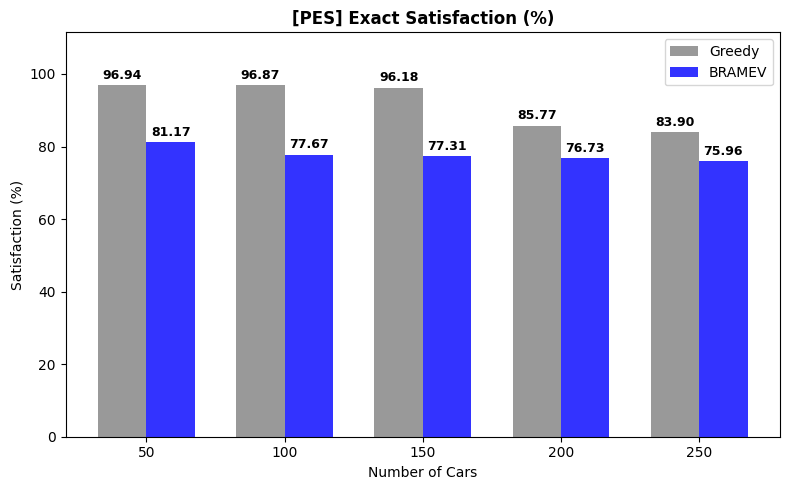

In [174]:
plot_exact_satisfaction(
    exact_satif_greedy_list,
    exact_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

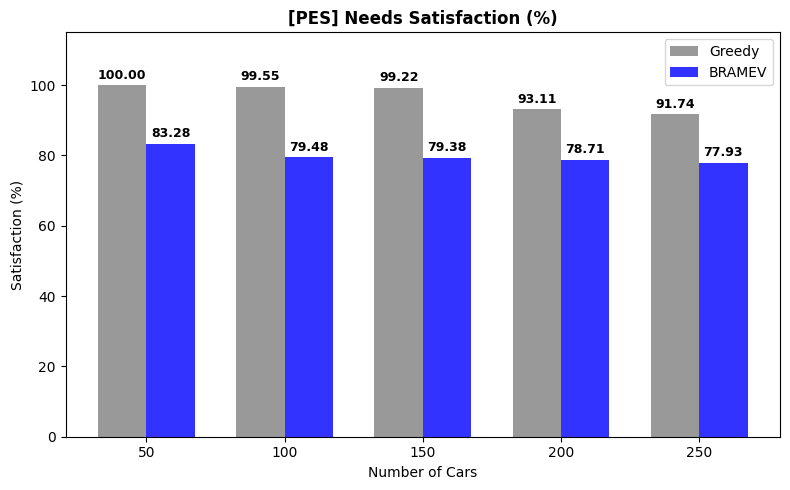

In [175]:
plot_needs_satisfaction(
    needs_satif_greedy_list,
    needs_satif_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)

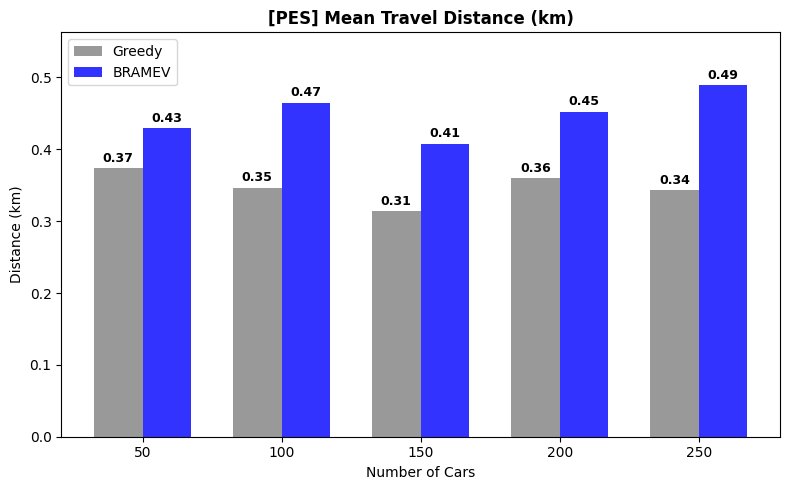

In [176]:
plot_mean_travel_distance(
    mean_travel_greedy_list,
    mean_travel_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


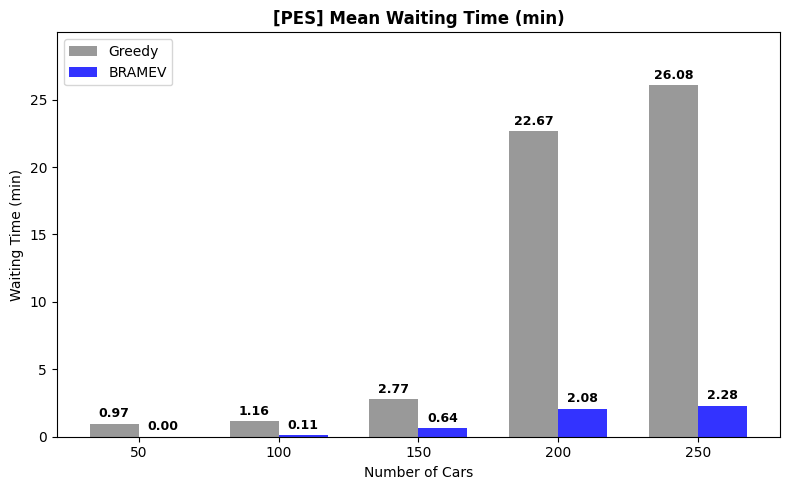

In [177]:
plot_mean_waiting_time(
    mean_waiting_greedy_list,
    mean_waiting_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)


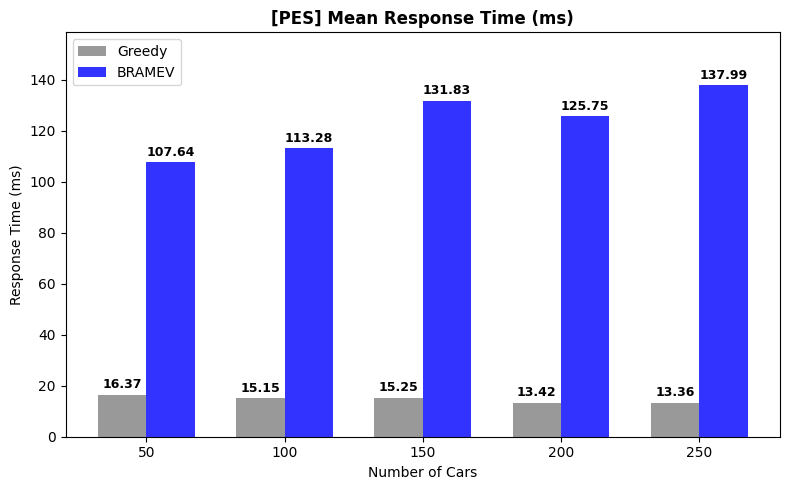

In [178]:
plot_mean_response_time(
    mean_response_greedy_list,
    mean_response_bramev_list,
    nb_car_list,
    colors,
    scenario_name=SCENARIO
)
